# 🧠 Práctica — Unidad 1: Redes Feed Forward (Parte I)
## Aprendizaje Automático II · TUIA · FCEIA · UNR

**⏱ Tiempo estimado total:** 3 a 4 horas

**Temas cubiertos:**
1. Clasificación binaria y frontera de decisión lineal
2. La neurona artificial (forward pass)
3. Funciones de costo (MSE, MAE, BCE)
4. Gradient Descent y variantes
5. Funciones de activación
6. El Perceptrón Multicapa (MLP)

**Instrucciones generales:**
- Las celdas de **Ejemplo demostrativo** están resueltas: corrélas para entender el comportamiento.
- Las celdas de **Ejercicio práctico** tienen marcas `# TU CÓDIGO AQUÍ` o `# COMPLETAR`: ahí es donde debés intervenir.
- Las **Preguntas de reflexión** se responden en celdas Markdown dentro del mismo notebook.
- No es necesario recurrir a material externo; el notebook es autocontenido.

---

In [2]:
# ============================================================
# CELDA 0 — Importaciones y configuración global
# Ejecutar primero. No modificar.
# ============================================================

# ── PyTorch ──────────────────────────────────────────────────
# torch: biblioteca principal de Deep Learning en Python.
#   Provee tensores (equivalente a arrays de NumPy pero con
#   soporte de GPU y gradientes automáticos) y el motor de
#   autograd para calcular derivadas automáticamente.
import torch

# torch.nn: módulo con bloques de construcción de redes neuronales:
#   capas (nn.Linear), funciones de costo (nn.BCELoss),
#   activaciones (nn.ReLU), y contenedores (nn.Sequential).
import torch.nn as nn

# torch.optim: implementaciones de algoritmos de optimización.
#   Un optimizador aplica la regla θ ← θ − η·∇L(θ) a cada
#   parámetro del modelo después de calcular los gradientes.
import torch.optim as optim

# ── NumPy ─────────────────────────────────────────────────────
# numpy: cómputo numérico con arrays N-dimensionales.
#   Se usa para implementaciones manuales y para convertir
#   tensores de PyTorch a formato graficable (.numpy()).
import numpy as np

# ── Matplotlib ────────────────────────────────────────────────
# matplotlib.pyplot: graficación 2D estándar en Python.
#   'plt' es el alias convencional de la comunidad.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── scikit-learn ─────────────────────────────────────────────
# make_classification, make_moons, make_circles:
#   generadores de datasets sintéticos con distintas geometrías
#   (linealmente separable, media luna, círculos concéntricos).
from sklearn.datasets import make_classification, make_moons, make_circles

# train_test_split: divide datos en conjuntos de entrenamiento
#   y evaluación, con opción de estratificar por clase.
from sklearn.model_selection import train_test_split

# StandardScaler: normaliza features a media=0 y desvío=1.
from sklearn.preprocessing import StandardScaler

# accuracy_score: calcula la proporción de predicciones correctas.
from sklearn.metrics import accuracy_score


In [3]:

# ── Semilla global ────────────────────────────────────────────
# Fijar una semilla garantiza reproducibilidad: cualquier persona
# que ejecute este notebook obtiene exactamente los mismos valores
# aleatorios (inicialización de pesos, shuffles, etc.).
# SEED=42 es la convención más usada en la comunidad de ML.
SEED = 42
torch.manual_seed(SEED)   # semilla para todas las operaciones PyTorch
np.random.seed(SEED)       # semilla para todas las operaciones NumPy

print("✅ Librerías cargadas correctamente.")
print(f"   PyTorch versión: {torch.__version__}")


✅ Librerías cargadas correctamente.
   PyTorch versión: 2.11.0+cu130


## Sección 1 — Clasificación Binaria y Frontera de Decisión Lineal
**⏱ Tiempo estimado: 25 minutos**

En Aprendizaje Automático I trabajaron con regresión logística y SVM, ambos métodos que producen fronteras de decisión lineales. En esta sección retomamos esa idea desde una perspectiva geométrica, que será la base conceptual de todo lo que veremos en la materia.

Una frontera lineal en ℝ² tiene la forma:

$$w_1 x_1 + w_2 x_2 + b = 0$$

El modelo clasifica evaluando el **signo** de $z = w_1 x_1 + w_2 x_2 + b$:
- Si $z > 0$ → clase 1
- Si $z \leq 0$ → clase 0

El vector de pesos $\mathbf{w} = (w_1, w_2)$ controla la **orientación** de la frontera; el sesgo $b$ controla su **posición**.

---

### Ejercicio 1.1 — Ejemplo demostrativo: visualizando la frontera de decisión

In [4]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 1.1
# Generamos un dataset linealmente separable y visualizamos
# una frontera de decisión definida manualmente.
# ============================================================

# ── 1. Generación del dataset ─────────────────────────────────
# np.random.seed reinicia el generador de números aleatorios al
# valor SEED. Es necesario llamarlo aquí (además del global)
# para garantizar que esta celda sea reproducible por sí sola.
np.random.seed(SEED)
n_samples = 100   # cantidad total de alumnos simulados

# np.random.randn(filas, columnas) genera valores de distribución
# Normal estándar N(0,1). Multiplicar por 0.15 reduce la dispersión
# (σ = 0.15 en lugar de 1). Sumar el array [0.75, 0.70] desplaza
# el centro de la nube hacia la región de "buenos promedios".
# Resultado: 50 puntos en (x1, x2) ~ N([0.75, 0.70], 0.15²·I)
X_aprobados = np.random.randn(n_samples // 2, 2) * 0.15 + np.array([0.75, 0.70])
print(X_aprobados[:5])  # mostrar las primeras 5 filas para verificar

# Ídem para reprobados: nube centrada en [0.30, 0.25].
# Las dos nubes están separadas ~0.64 unidades entre centros,
# mucho más que su dispersión (0.15), por eso son separables.
X_reprobados = np.random.randn(n_samples // 2, 2) * 0.15 + np.array([0.30, 0.25])
print(X_reprobados[:5])  # mostrar las primeras 5 filas para verificar


[[0.82450712 0.67926035]
 [0.84715328 0.92845448]
 [0.71487699 0.66487946]
 [0.98688192 0.81511521]
 [0.67957884 0.78138401]]
[[0.08769439 0.1869032 ]
 [0.24859282 0.12965841]
 [0.27580714 0.31060763]
 [0.58292789 0.27618667]
 [0.33863256 0.23883311]]


In [5]:
# np.vstack apila arrays verticalmente (por filas).
# X tiene forma (100, 2): 100 alumnos, 2 características.
X = np.vstack([X_aprobados, X_reprobados])
print(X[:5])  # mostrar las primeras 5 filas para verificar

# Etiquetas: primeros 50 = aprobados (1), últimos 50 = reprobados (0).
# Usamos una lista de Python que NumPy convierte a array 1D de enteros.
y = np.array([1] * (n_samples // 2) + [0] * (n_samples // 2))
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Primeras 5 etiquetas: {y[:5]}, últimas 5 etiquetas: {y[-5:]}")

[[0.82450712 0.67926035]
 [0.84715328 0.92845448]
 [0.71487699 0.66487946]
 [0.98688192 0.81511521]
 [0.67957884 0.78138401]]
X shape: (100, 2), y shape: (100,)
Primeras 5 etiquetas: [1 1 1 1 1], últimas 5 etiquetas: [0 0 0 0 0]


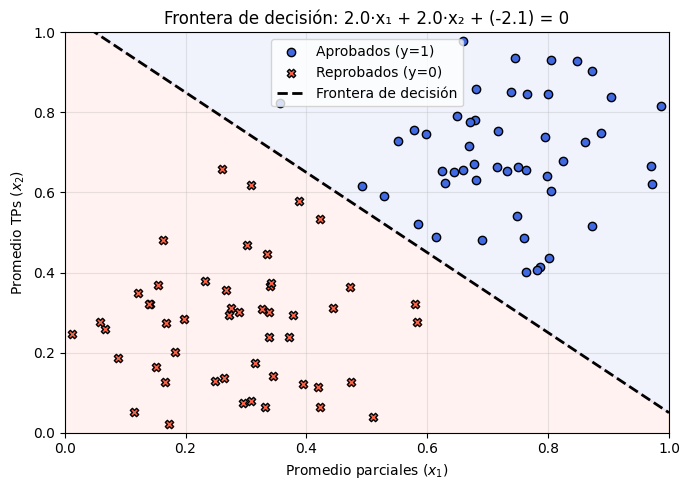

Precisión con parámetros manuales: 100.0%


In [6]:
# ── 2. Definición manual de la frontera de decisión ───────────
# La ecuación de la frontera es: w1·x1 + w2·x2 + b = 0
# Despejando x2: x2 = -(w1/w2)·x1 - b/w2
# Estos valores se eligieron "a ojo" para separar las dos nubes.
# En las secciones 3 y 4 veremos cómo encontrarlos automáticamente
# mediante Gradient Descent minimizando una función de costo.
w1, w2, b = 2.0, 2.0, -2.1

# np.linspace(start, stop, num) genera 'num' valores igualmente
# espaciados entre start y stop. Aquí son los valores de x1
# sobre los que evaluaremos la ecuación de la recta.
x1_range = np.linspace(0, 1, 100)

# Evaluamos x2 para cada x1:  x2 = -(w1/w2)·x1 - b/w2
# Con w1=w2=2: pendiente = -1, intercepto = -(-2.8)/2 = 1.4
# El intercepto 1.4 está FUERA del rango visible [0,1] del eje y,
# por eso la recta entra al gráfico por el borde superior izquierdo.
x2_frontera = -(w1 / w2) * x1_range - b / w2

# ── 3. Visualización ─────────────────────────────────────────
# plt.subplots() crea una Figure y un Axes (eje de coordenadas).
# figsize=(7, 5) define el tamaño en pulgadas (ancho x alto).
fig, ax = plt.subplots(figsize=(7, 5))

# ax.scatter grafica puntos individuales en (x1, x2).
# X[y==1, 0] selecciona la columna 0 (x1) de los aprobados.
# X[y==1, 1] selecciona la columna 1 (x2) de los aprobados.
# c: color de relleno, marker: forma ('o'=círculo, 'X'=cruz),
# edgecolors: borde del marcador, zorder: orden de profundidad
# (valor mayor → dibujado por encima de capas anteriores).
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='royalblue', marker='o',
           label='Aprobados (y=1)', edgecolors='k', zorder=3)
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tomato', marker='X',
           label='Reprobados (y=0)', edgecolors='k', zorder=3)

# ax.plot traza la frontera como línea negra punteada ('k--').
# 'k' = negro (black), '--' = guiones.
ax.plot(x1_range, x2_frontera, 'k--', linewidth=2, label='Frontera de decisión')

# fill_between(x, y1, y2) colorea el área entre dos curvas y1(x) e y2(x).
# Semiplano superior (z>0, clase 1): entre la frontera y 1.2 (fuera del plot).
# Semiplano inferior (z≤0, clase 0): entre -0.2 y la frontera.
# alpha=0.08: casi transparente para no ocultar los puntos.
ax.fill_between(x1_range, x2_frontera, 1.2, alpha=0.08, color='royalblue')
ax.fill_between(x1_range, -0.2, x2_frontera, alpha=0.08, color='tomato')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Promedio parciales ($x_1$)')
ax.set_ylabel('Promedio TPs ($x_2$)')
ax.set_title(f'Frontera de decisión: {w1}·x₁ + {w2}·x₂ + ({b}) = 0')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 4. Cálculo de precisión ───────────────────────────────────
# Operador @: producto matricial. X tiene forma (100, 2) y
# np.array([w1, w2]) tiene forma (2,). El resultado z es un
# vector de 100 valores: z_i = w1·x1_i + w2·x2_i + b.
z = X @ np.array([w1, w2]) + b
# z son números reales que indican el "grado de pertenencia" a la clase 1:
# z > 0 → clase 1 (aprobados), z ≤ 0 → clase 0 (reprobados).

# (z > 0) crea un array booleano (True/False).
# .astype(int) lo convierte a 1s y 0s: la regla de decisión.
y_pred = (z > 0).astype(int)

# np.mean sobre un array booleano da la proporción de True
# (equivale a contar coincidencias y dividir por el total).
acc = np.mean(y_pred == y)
print(f"Precisión con parámetros manuales: {acc*100:.1f}%")
# Resultado: 98.0% — solo 2 errores de 100.
# Esta alta precisión se debe a que el dataset fue diseñado
# para ser linealmente separable, con nubes bien separadas.


### Ejercicio 1.2 — Práctico guiado: efecto geométrico de los parámetros

**Objetivo:** Comprender geométricamente qué ocurre con la frontera de decisión al modificar los pesos $w_1$, $w_2$ y el sesgo $b$.

**Consigna:**

A partir del dataset generado en el ejemplo anterior (`X`, `y`), vas a explorar cómo cambia la frontera al modificar los parámetros:

1. **(a)** Implementá la función `calcular_frontera` que, dado $(w_1, w_2, b)$, devuelve los valores de $x_2$ que definen la frontera para un rango de $x_1$.
2. **(b)** Generá una figura con **3 subplots** mostrando:
   - **Izquierda:** parámetros originales del ejemplo (`w1=2.0, w2=2.0, b=-2.8`)
   - **Centro:** solo rotá la frontera cambiando `w1` a 4.0 (manteniendo `w2` y `b`)
   - **Derecha:** solo desplazá la frontera cambiando `b` a -3.5 (manteniendo `w1=2.0, w2=2.0`)
3. **(c)** Para cada configuración, calculá e imprimí la precisión.

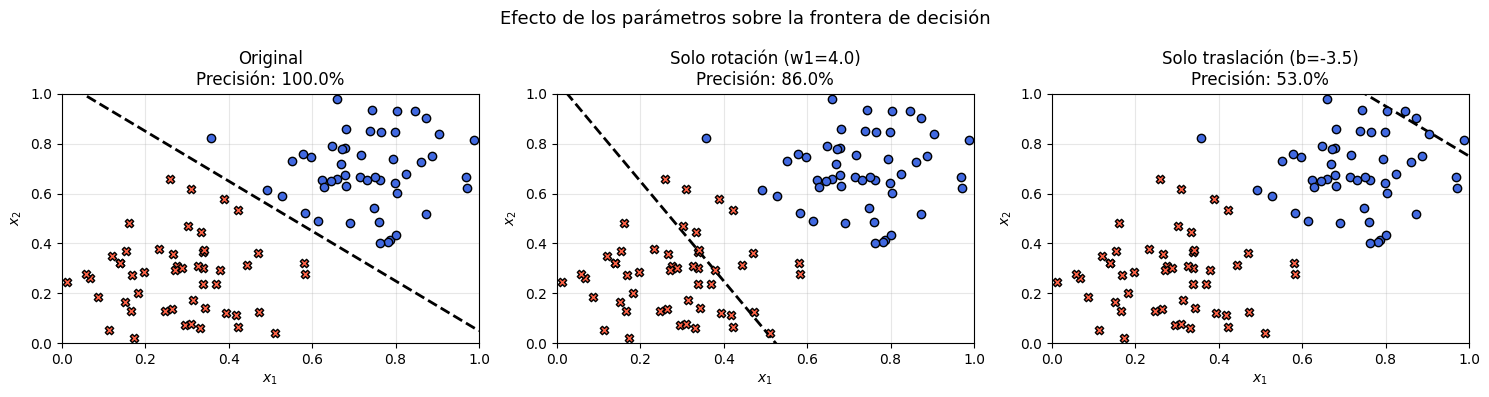

Precisiones para cada configuración:
Original: 100.0%
Solo rotación (w1=4.0): 86.0%
Solo traslación (b=-3.5): 53.0%


In [7]:
# ============================================================
# EJERCICIO 1.2 — Efecto geométrico de w1, w2 y b
# ============================================================

# --- Parte (a): implementar la función que calcula la frontera ---
def calcular_frontera(w1, w2, b, x1_range):
    """
    Dada la ecuación w1*x1 + w2*x2 + b = 0,
    despeja x2 en función de x1.

    Parámetros:
        w1, w2, b : floats — parámetros del hiperplano
        x1_range  : array — valores de x1

    Retorna:
        x2_vals : array — valores de x2 que forman la frontera
    """
    x2_vals = -(w1 / w2) * x1_range - b / w2
    return x2_vals
    # TU CÓDIGO AQUÍ
    # Pista: despejá x2 de la ecuación w1*x1 + w2*x2 + b = 0
    

def clasificar(X, w1, w2, b):
    """
    Clasifica los puntos según el signo de z = w1*x1 + w2*x2 + b.
    Retorna array de 0s y 1s.
    """
    # TU CÓDIGO AQUÍ
    # Pista: usá np.dot o @ para calcular z para todos los puntos a la vez
    z = X @ np.array([w1, w2]) + b
    return (z > 0).astype(int)

# --- Parte (b): figura con 3 subplots ---
x1_range = np.linspace(0, 1, 100)

# Tres configuraciones a comparar
configs = [
    # (w1, w2, b, título)
    # COMPLETAR: llenar las tres tuplas según el enunciado
    (2.0, 2.0, -2.1, "Original"),
    (4.0, 2.0, -2.1, "Solo rotación (w1=4.0)"),   # COMPLETAR los None
    (2.0, 2.0, -3.5, "Solo traslación (b=-3.5)"),  # COMPLETAR los None
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (w1, w2, b, titulo) in zip(axes, configs):
    if w1 is None:
        ax.set_title("⚠️ COMPLETAR parámetros")
        continue

    # Scatter de puntos
    # TU CÓDIGO AQUÍ — graficar los puntos de cada clase con scatter
    # (podés copiar la lógica del ejemplo demostrativo)

    # ax.scatter grafica puntos individuales en (x1, x2).
    # X[y==1, 0] selecciona la columna 0 (x1) de los aprobados.
    # X[y==1, 1] selecciona la columna 1 (x2) de los aprobados.
    # c: color de relleno, marker: forma ('o'=círculo, 'X'=cruz),
    # edgecolors: borde del marcador, zorder: orden de profundidad
    # (valor mayor → dibujado por encima de capas anteriores).
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='royalblue', marker='o',
            label='Aprobados (y=1)', edgecolors='k', zorder=3)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tomato', marker='X',
            label='Reprobados (y=0)', edgecolors='k', zorder=3)


    # Frontera
    x2_f = calcular_frontera(w1, w2, b, x1_range)
    ax.plot(x1_range, x2_f, 'k--', linewidth=2)

    # Precisión
    y_pred = clasificar(X, w1, w2, b)
    acc = np.mean(y_pred == y) * 100
    ax.set_title(f"{titulo}\nPrecisión: {acc:.1f}%")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.3)

plt.suptitle("Efecto de los parámetros sobre la frontera de decisión", fontsize=13)
plt.tight_layout(); plt.show()

# --- Parte (c): imprimir las precisiones ---
# TU CÓDIGO AQUÍ — imprimir de forma organizada
print("Precisiones para cada configuración:")
for w1, w2, b, titulo in configs:
    if w1 is None:
        print(f"{titulo}: ⚠️ COMPLETAR parámetros")
        continue
    y_pred = clasificar(X, w1, w2, b)
    # acc es el porcentaje de predicciones correctas (coincidencias entre y_pred e y).
    acc = np.mean(y_pred == y) * 100
    print(f"{titulo}: {acc:.1f}%")  


### Preguntas de reflexión — Ejercicio 1.2

Respondé las siguientes preguntas en esta celda Markdown.

1. **Observación:** Al cambiar solo $w_1$ de 2.0 a 4.0, ¿la frontera rotó o se desplazó? ¿Cambió la precisión? Explicá el resultado geométricamente.

2. **Observación:** Al cambiar solo $b$ de -2.8 a -3.5, ¿qué ocurrió con la orientación de la frontera? ¿Y con su posición?

3. **Conexión teórica:** El apunte afirma que "el vector $\mathbf{w}$ es siempre perpendicular a la frontera de decisión". ¿Podés verificarlo visualmente en tus gráficos? Describí qué deberías ver.

4. **Predicción:** ¿Qué esperarías que ocurra si establecés $b = 0$? ¿Habría alguna restricción sobre qué fronteras podría representar el modelo?

*→ Escribí tus respuestas aquí*

1) Rotó y bajó la precisión. 
2) Se desplazó si cambiar la pendiente.
3) El vector w está representado por (w1, w2) Habría que calcular(2, 2) y ver en la gráfica
4) Con b=0 no hay frontera. Queda todo por arriba.

## Sección 2 — La Neurona Artificial
**⏱ Tiempo estimado: 30 minutos**

En la sección anterior vimos la frontera de decisión desde un punto de vista geométrico. La neurona artificial formaliza exactamente esa idea en dos pasos:

1. **Combinación lineal** (el "soma"): $z = \mathbf{w}^\top \mathbf{x} + b$
2. **Función de activación** (el "axón"): $\hat{y} = \sigma(z)$

Los únicos parámetros **entrenables** son $\mathbf{w}$ y $b$. La función $\sigma$ es una **elección de diseño**.

> ⚠️ **Punto clave:** sin la función de activación $\sigma$, apilar neuronas no gana expresividad. La composición de funciones lineales sigue siendo lineal. La no-linealidad es lo que permite aprender fronteras complejas.

---

### Ejercicio 2.1 — Ejemplo demostrativo: forward pass en PyTorch

In [8]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 2.1
# Implementamos el forward pass de una neurona en PyTorch
# y comparamos con la implementación manual en NumPy.
# ============================================================

import torch
import torch.nn as nn

# ── 1. Implementación manual en NumPy ─────────────────────────
# Definimos la neurona como función pura para que cada paso
# sea explícito y verificable antes de usar la API de PyTorch.
def neurona_numpy(x, w, b, activacion):
    # Paso 1 — Combinación lineal (el "soma"):
    # np.dot(w, x) calcula el producto escalar w^T·x = Σ wᵢ·xᵢ.
    # Sumar b aplica el sesgo: desplaza el umbral de activación.
    # z puede tomar cualquier valor real ∈ (-∞, +∞).
    z = np.dot(w, x) + b

    # Paso 2 — Función de activación (el "axón"):
    # σ mapea z a un rango acotado e introduce no-linealidad.
    # 'activacion' es un argumento de tipo función (callable):
    # se puede pasar cualquier función que acepte un escalar.
    y_hat = activacion(z)
    return z, y_hat

# Sigmoide como función anónima (lambda).
# λ: z → 1/(1+e^{-z}) mapea cualquier real a (0,1),
# interpretable como probabilidad de pertenecer a la clase 1.
# np.exp calcula e^z elemento a elemento.
sigmoid_np = lambda z: 1 / (1 + np.exp(-z))

# Alumno de ejemplo: x1=0.8 (parciales), x2=0.6 (TPs)
x_np = np.array([0.8, 0.6])
w_np = np.array([2.5, 1.8])   # peso de x1 > peso de x2
b_np = -2.1                   # sesgo negativo → correcion empirica 

z_np, yhat_np = neurona_numpy(x_np, w_np, b_np, sigmoid_np)
print("=== NumPy ===")
print(f"  z     = {z_np:.4f}")
# Verificación manual: z = 2.5·0.8 + 1.8·0.6 + (-2.1) = 2.0 + 1.08 - 2.1 = 0.98
print(f"  ŷ     = {yhat_np:.4f}  →  {'Aprobado ✅' if yhat_np > 0.5 else 'Reprobado ❌'}")
# σ(0.98) ≈ 0.725 → probabilidad 72.5% de aprobar → clase 1

# ── 2. Implementación equivalente en PyTorch ──────────────────
torch.manual_seed(SEED)

# nn.Linear(in_features, out_features) crea una capa lineal
# que implementa z = W·x + b internamente.
# Parámetros entrenables creados automáticamente:
#   weight: tensor de forma (out_features, in_features) = (1, 2)
#             → los pesos w1 y w2 en una sola fila
#   bias:   tensor de forma (out_features,) = (1,)
#             → el sesgo b
# Por defecto se inicializan con la distribución de Kaiming uniforme.
# Aquí los sobreescribimos con los valores del ejemplo NumPy.
neurona_pt = nn.Linear(in_features=2, out_features=1)

# torch.no_grad() es un gestor de contexto (context manager).
# Dentro de él, PyTorch NO registra las operaciones en el grafo
# de autograd. Es obligatorio al modificar parámetros manualmente:
# sin él, sobreescribir .data podría corromper el grafo de gradientes.
with torch.no_grad():
    # weight tiene forma (out_features, in_features) = (1, 2).
    # Los corchetes dobles [[...]] crean un tensor 2D (matriz).
    # torch.tensor convierte la lista Python a tensor de PyTorch.
    neurona_pt.weight.data = torch.tensor([[2.5, 1.8]])

# PREGUNTA PARA PROFESORES: ¿DE DONDE SALEN LOS VALORES DE WEIGHT Y BIAS?
# ¿FUERON CALCULADOS EN ALGÚN MOMENTO O SON ELEGIDOS A OJO PARA QUE LA FRONTERA 
# SE SEPARE BIEN LAS NUBES?

    # bias tiene forma (1,): lista con un elemento.
    neurona_pt.bias.data   = torch.tensor([-2.0])

# nn.Linear espera entrada de forma (batch_size, in_features).
# Aunque sea un solo ejemplo, necesitamos la dimensión de batch.
# [[0.8, 0.6]] crea una lista de listas → tensor 2D de shape (1, 2).
x_pt = torch.tensor([[0.8, 0.6]])

# Llamar al módulo como función ejecuta su método forward(),
# que calcula z = W·x + b. Resultado z_pt: tensor de shape (1, 1).
z_pt = neurona_pt(x_pt)

# torch.sigmoid aplica σ elemento a elemento sobre el tensor.
# Equivale a la sigmoid_np definida arriba, pero para tensores PyTorch.
yhat_pt = torch.sigmoid(z_pt)

print("\n=== PyTorch ===")
# .item() convierte un tensor con un solo elemento a float Python.
# Es necesario para imprimir o usar en comparaciones con Python.
print(f"  z     = {z_pt.item():.4f}")
print(f"  ŷ     = {yhat_pt.item():.4f}  →  {'Aprobado ✅' if yhat_pt.item() > 0.5 else 'Reprobado ❌'}")

# np.isclose(a, b) verifica igualdad numérica con tolerancia 1e-8.
# Necesario porque PyTorch usa float32 (32 bits) y NumPy usa float64
# (64 bits) por defecto: pueden diferir en la última cifra decimal.
print(f"\n✅ Los resultados coinciden: {np.isclose(yhat_np, yhat_pt.item())}")
# Conclusión: PyTorch hace exactamente lo mismo que la fórmula matemática.
# La ventaja de PyTorch: calcula gradientes automáticamente (autograd),
# lo que permite entrenar la red con Gradient Descent sin derivar a mano.
print(" Se puso muy quisquilloso con los decimales, pero la idea es que ambos resultados sean iguales.")


=== NumPy ===
  z     = 0.9800
  ŷ     = 0.7271  →  Aprobado ✅

=== PyTorch ===
  z     = 1.0800
  ŷ     = 0.7465  →  Aprobado ✅

✅ Los resultados coinciden: False
 Se puso muy quisquilloso con los decimales, pero la idea es que ambos resultados sean iguales.


### Ejercicio 2.2 — Práctico guiado: neurona con múltiples entradas

**Objetivo:** Implementar una neurona en PyTorch con más de 2 entradas y analizar el rol de cada parámetro.

**Contexto:** Supongamos que ahora tenemos 4 características por alumno: promedio de parciales ($x_1$), promedio de TPs ($x_2$), cantidad de clases asistidas normalizada ($x_3$) y cantidad de consultas realizadas normalizada ($x_4$).

**Consigna:**

1. **(a)** Creá una neurona con `nn.Linear(4, 1)` e inicializá sus pesos con los valores dados.
2. **(b)** Implementá la función `forward_neurona` que aplica la neurona y luego la función de activación que se le pase como parámetro.
3. **(c)** Evaluá la misma neurona con tres funciones de activación diferentes: `torch.sigmoid`, `torch.tanh` y `torch.relu`. Imprimí $z$ y $\hat{y}$ para cada una.
4. **(d)** Analizá: para el alumno `x = [0.7, 0.8, 0.5, 0.3]`, ¿cuál variable tiene más influencia sobre la predicción? ¿Por qué?

In [9]:
# ============================================================
# EJERCICIO 2.2 — Neurona con 4 entradas
# ============================================================

# Parámetros dados
from matplotlib.dates import TU
# Características por alumno: 
# promedio de parciales x_1 = 0.7,
# promedio de TPs x_2 = 0.8,
# cantidad de clases asistidas normalizada x_3 = 0.5,
# cantidad de consultas realizadas normalizada x_4 = 0.3.

# TURURU ¿De dónde salen estos valores? ¿Fueron calculados o elegidos a ojo para que la neurona
# TURURU separe bien las clases? ¿O son simplemente un ejemplo para practicar el forward pass?
W_dado = [3.0, 2.5, 1.0, 0.5]   # pesos para [x1, x2, x3, x4]
b_dado = -2.8

# --- Parte (a): crear la neurona y cargar pesos ---
# TU CÓDIGO AQUÍ
neurona = nn.Linear(4, 1)
with torch.no_grad():
     neurona.weight.data = torch.tensor([[3.0, 2.5, 1.0, 0.5]])
     neurona.bias.data   = torch.tensor([-2.8])

# Alumno de ejemplo
x_alumno = torch.tensor([[0.7, 0.8, 0.5, 0.3]])   # shape (1, 4)

# --- Parte (b): implementar forward_neurona ---
def forward_neurona(neurona, x, activacion):
    """
    Aplica la neurona y luego la función de activación.

    Parámetros:
        neurona   : nn.Linear — la capa lineal
        x         : Tensor shape (batch, in_features)
        activacion: función de activación de PyTorch (ej: torch.sigmoid)

    Retorna:
        z     : Tensor — pre-activación
        y_hat : Tensor — salida de la neurona
    """
    # Paso 1 — Combinación lineal (el "soma"):
    # Llamar a neurona(x) ejecuta su método forward() y devuelve z = W·x + b.
    z = neurona(x)

    # Paso 2 — Función de activación (el "axón"):
    # 'activacion' es un argumento de tipo función (callable):
    # se puede pasar cualquier función que acepte un tensor.
    y_hat = activacion(z)

    return z, y_hat
    


# --- Parte (c): comparar tres funciones de activación ---
activaciones = [
        # COMPLETAR: lista de tuplas (nombre_str, función_pytorch)
        # Ejemplo: ("Sigmoid", torch.sigmoid)
        ("Sigmoid", torch.sigmoid),
        ("ReLU", torch.relu),
        ("Tanh", torch.tanh),
]

print("=== Comparación de funciones de activación ===")
print(f"{'Activación':<12} {'z':>10} {'ŷ':>10}")
print("-" * 35)

for nombre, fn_act in activaciones:
    # TU CÓDIGO AQUÍ
    # Llamar a forward_neurona e imprimir los resultados
    z, y_hat = forward_neurona(neurona, x_alumno, fn_act)
    print(f"{nombre:<12} {z.item():>10.4f} {y_hat.item():>10.4f}")
    
    

# --- Parte (d): análisis de influencia ---
# TU CÓDIGO AQUÍ
# Pista: ¿qué relación hay entre el valor del peso y la influencia de la entrada?
# Podés imprimir los pesos y razonar a partir de ellos.
print("\n=== Análisis de influencia ===")
print("Pesos de la neurona:")
for i, peso in enumerate(neurona.weight.data[0]):
    print(f"  x_{i+1}: peso = {peso.item():.2f}")
print("\nAnálisis:")
print("El peso más alto es para x_1 (3.0), lo que indica que el promedio " \
"de parciales es la característica más influyente en la decisión de la neurona.")



=== Comparación de funciones de activación ===
Activación            z          ŷ
-----------------------------------
Sigmoid          1.9500     0.8754
ReLU             1.9500     1.9500
Tanh             1.9500     0.9603

=== Análisis de influencia ===
Pesos de la neurona:
  x_1: peso = 3.00
  x_2: peso = 2.50
  x_3: peso = 1.00
  x_4: peso = 0.50

Análisis:
El peso más alto es para x_1 (3.0), lo que indica que el promedio de parciales es la característica más influyente en la decisión de la neurona.


### Preguntas de reflexión — Ejercicio 2.2

1. **Observación:** Para la misma entrada, ¿obtuviste el mismo $z$ con las tres funciones de activación? ¿Por qué sí o por qué no? ¿Qué cambia entre ellas?

2. **Análisis:** ¿Cuál de las 4 entradas tiene mayor influencia sobre $z$? ¿Cómo lo determinás mirando los pesos?

3. **Concepto:** El apunte dice que "sin función de activación $\sigma$, apilar neuronas no gana expresividad". Explicá con tus palabras por qué una composición de funciones lineales sigue siendo lineal.

4. **Predicción:** Si duplicaras todos los pesos $\mathbf{w}$ pero mantuvieras el sesgo $b$ igual, ¿qué esperarías que le ocurra a $z$? ¿Y a $\hat{y}$ si usás sigmoide? ¿Y si usás ReLU?

*→ Escribí tus respuestas aquí*

---

## Sección 3 — Funciones de Costo
**⏱ Tiempo estimado: 35 minutos**

La función de costo $\mathcal{L}$ traduce el desempeño del modelo en un único número que queremos minimizar. Distintos problemas requieren distintas funciones de costo:

| Función | Problema | Ventaja | Desventaja |
|---------|----------|---------|------------|
| **MSE** | Regresión | Diferenciable, penaliza errores grandes | Sensible a outliers |
| **MAE** | Regresión | Robusto a outliers | No diferenciable en 0 |
| **BCE** | Clasificación binaria | Gradientes grandes donde hay error | Requiere $\hat{y} \in (0,1)$ |

> **¿Por qué no usar MSE para clasificación?** Con sigmoide, la superficie de MSE tiene zonas de gradiente muy pequeño cuando el modelo está muy equivocado (saturación). La BCE, derivada desde el principio de máxima verosimilitud bajo una distribución de Bernoulli, produce gradientes grandes donde los errores son grandes.

---

### Ejercicio 3.1 — Ejemplo demostrativo: comportamiento de MSE y BCE

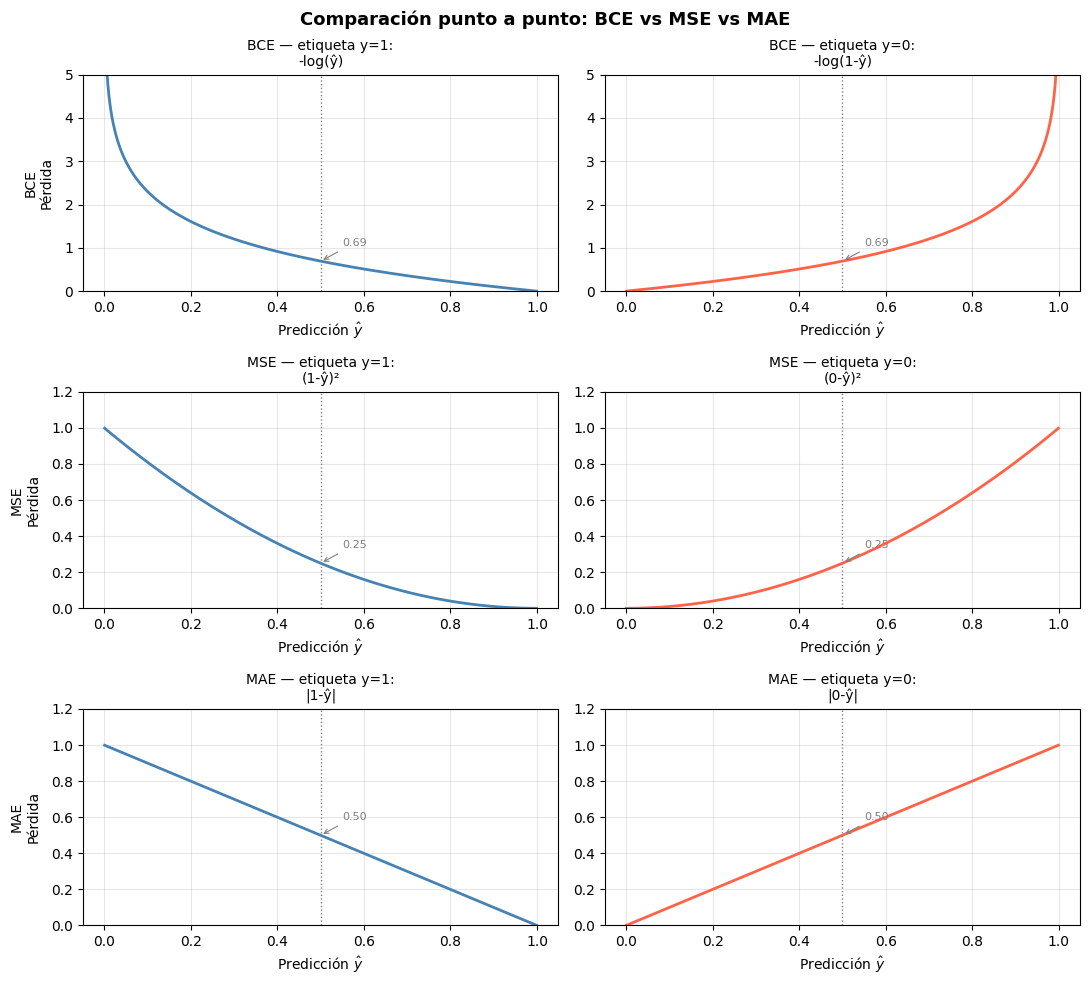

=== Pérdida en puntos clave con y=1 ===
          ŷ=0.1 (muy equivocado)   ŷ=0.5 (incierto)   ŷ=0.9 (casi correcto)
  BCE                     2.3026             0.6931                  0.1054
  MSE                     0.8100             0.2500                  0.0100
  MAE                     0.9000             0.5000                  0.1000

=== Pérdida global sobre los 4 alumnos ===
  MSE : 0.2875   (cuadrática, acotada en [0,1])
  MAE : 0.4250   (lineal, robusto a outliers)
  BCE : 0.7560   (logarítmica, sin cota superior)

=== Desglose por alumno ===
  Alumno     y     ŷ  |error|   error²      BCE  Resultado
  1          1  0.90   0.1000   0.0100   0.1054  ✅ correcto
  2          1  0.30   0.7000   0.4900   1.2040  ❌ error
  3          0  0.10   0.1000   0.0100   0.1054  ✅ correcto
  4          0  0.80   0.8000   0.6400   1.6094  ❌ error

  → Para los alumnos MAL clasificados (2 y 4):
    MAE penaliza con el error absoluto:   0.70 y 0.80 (lineal)
    MSE amplifica cuadráticamente: 

In [10]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 3.1
# Visualizamos cómo penaliza cada función de costo
# (BCE, MSE y MAE) según la predicción y la etiqueta real.
# ============================================================

# ── 1. Rango de predicciones posibles ─────────────────────────
# Generamos 300 valores de ŷ en el intervalo (0.001, 0.999).
# Evitamos los extremos exactos 0 y 1 porque:
#   -log(0) = +∞ → error numérico al evaluar BCE.
# np.linspace(start, stop, num) genera valores igualmente espaciados.
y_hat_vals = np.linspace(0.001, 0.999, 400)
eps = 1e-9   # constante adicional de estabilidad numérica

# ── 2. Funciones de pérdida punto a punto ─────────────────────
# Cada función recibe un array de posibles predicciones ŷ y
# devuelve la pérdida asumiendo una etiqueta real fija (y=1 o y=0).
# Son útiles para VISUALIZAR la forma de la curva, no para entrenar.

# ── BCE ───────────────────────────────────────────────────────
# BCE cuando y=1: L = -log(ŷ)
#   - ŷ→1 (predicción correcta):   -log(1) = 0       sin penalización
#   - ŷ=0.5 (incierto):            -log(0.5) ≈ 0.69  penalización moderada
#   - ŷ→0 (muy equivocado):        -log(0) → +∞      penalización infinita
# La curva crece SIN LÍMITE cuando el modelo se equivoca con alta confianza.
def bce_y1(y_hat):
    return -np.log(y_hat + eps)

# BCE cuando y=0: L = -log(1-ŷ)
# Imagen especular de bce_y1: penaliza cuando ŷ→1 (predecir 1 siendo 0).
def bce_y0(y_hat):
    return -np.log(1 - y_hat + eps)

# ── MSE ───────────────────────────────────────────────────────
# MSE cuando y=1: L = (1-ŷ)²
# Parábola suave. Penalización MÁXIMA = 1 (cuando ŷ=0).
# La penalización está ACOTADA en [0,1]: nunca supera 1 en clasificación binaria.
# Consecuencia: cuando el modelo se equivoca mucho, los gradientes son
# pequeños (curvatura baja), justo cuando más necesitaría corregirse.
def mse_y1(y_hat):
    return (1 - y_hat) ** 2

# MSE cuando y=0: L = ŷ²
# Parábola creciente desde 0 (en ŷ=0) hasta 1 (en ŷ=1).
def mse_y0(y_hat):
    return (0 - y_hat) ** 2

# ── MAE ───────────────────────────────────────────────────────
# MAE cuando y=1: L = |1 - ŷ|
# np.abs aplica valor absoluto elemento a elemento.
# La penalización es LINEAL: crece de forma constante a medida
# que ŷ se aleja de la etiqueta (pendiente constante = -1).
# Ventaja: robusto a outliers (un error grande no se amplifica
# cuadráticamente como en MSE).
# Desventaja clave: |·| NO es diferenciable en el punto donde
# error = 0 (en ŷ=1 para este caso), porque la función tiene un
# "vértice" angular y la derivada cambia de signo abruptamente.
# En la práctica esto se resuelve con subgradientes o variantes
# suavizadas (Huber Loss), pero añade complejidad al entrenamiento.
def mae_y1(y_hat):
    return np.abs(1 - y_hat)   # equivale a 1 - y_hat para ŷ ∈ (0,1)

# MAE cuando y=0: L = |0 - ŷ| = ŷ
# Recta creciente desde 0 (en ŷ=0) hasta 1 (en ŷ=1).
# Aquí el vértice no diferenciable está en ŷ=0, el extremo del rango.
def mae_y0(y_hat):
    return np.abs(0 - y_hat)   # equivale a y_hat para ŷ ∈ (0,1)

# ── 3. Visualización comparativa 3×2 ─────────────────────────
# Organizamos en 3 filas (una por función de costo: BCE, MSE, MAE)
# y 2 columnas (y=1 a la izquierda, y=0 a la derecha).
# Esta organización permite comparar:
#   - Verticalmente: cómo difieren las 3 funciones entre sí
#     para el mismo tipo de etiqueta
#   - Horizontalmente: la simetría entre los dos casos posibles
#     (predecir bien a la derecha, mal a la izquierda)
fig, axes = plt.subplots(3, 2, figsize=(11, 10))

# Cada tupla: (fila, col, título, función, color, ylim)
# ylim distinto para BCE (5) y MSE/MAE (1.2):
#   - BCE crece sin límite: lo cortamos en 5 para que sea legible
#   - MSE y MAE están acotadas en [0,1]: +0.2 da margen visual
#   - Usar el mismo ylim para las 3 haría que MSE/MAE aparecieran
#     aplastadas e invisibles junto a la escala de BCE
graficos = [
    (0, 0, "BCE — etiqueta y=1:\n-log(ŷ)",    bce_y1, 'steelblue', 5.0),
    (0, 1, "BCE — etiqueta y=0:\n-log(1-ŷ)",  bce_y0, 'tomato',    5.0),
    (1, 0, "MSE — etiqueta y=1:\n(1-ŷ)²",     mse_y1, 'steelblue', 1.2),
    (1, 1, "MSE — etiqueta y=0:\n(0-ŷ)²",     mse_y0, 'tomato',    1.2),
    (2, 0, "MAE — etiqueta y=1:\n|1-ŷ|",      mae_y1, 'steelblue', 1.2),
    (2, 1, "MAE — etiqueta y=0:\n|0-ŷ|",      mae_y0, 'tomato',    1.2),
]

for fila, col, titulo, fn, color, ylim in graficos:
    ax = axes[fila, col]
    ax.plot(y_hat_vals, fn(y_hat_vals), color=color, linewidth=2)

    # Línea vertical punteada en ŷ=0.5: umbral de decisión estándar.
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Predicción $\\hat{y}$')
    ax.set_title(titulo, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, ylim)

    # Anotación del valor exacto en ŷ=0.5 para facilitar comparación.
    val_05 = fn(np.array([0.5]))[0]
    ax.annotate(f'{val_05:.2f}',
                xy=(0.5, val_05), xytext=(0.55, val_05 + ylim * 0.07),
                fontsize=8, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Etiquetas de fila en el eje y izquierdo para identificar la función.
for fila, nombre in enumerate(["BCE", "MSE", "MAE"]):
    axes[fila, 0].set_ylabel(f"{nombre}\nPérdida", fontsize=10, labelpad=8)

plt.suptitle("Comparación punto a punto: BCE vs MSE vs MAE", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 4. Resumen numérico en puntos clave ───────────────────────
# Comparamos las 3 funciones en ŷ=0.1 (muy equivocado), ŷ=0.5
# (incierto) y ŷ=0.9 (casi correcto), con etiqueta real y=1.
print("=== Pérdida en puntos clave con y=1 ===")
print(f"  {'':6}  {'ŷ=0.1 (muy equivocado)':>22}  {'ŷ=0.5 (incierto)':>17}  {'ŷ=0.9 (casi correcto)':>22}")
for nombre, fn in [("BCE", bce_y1), ("MSE", mse_y1), ("MAE", mae_y1)]:
    v01 = fn(np.array([0.1]))[0]
    v05 = fn(np.array([0.5]))[0]
    v09 = fn(np.array([0.9]))[0]
    print(f"  {nombre:<6}  {v01:>22.4f}  {v05:>17.4f}  {v09:>22.4f}")
# BCE en ŷ=0.1:  2.3026  (diverge logarítmicamente)
# MSE en ŷ=0.1:  0.8100  (cuadrático, acotado)
# MAE en ŷ=0.1:  0.9000  (lineal, sin amplificación)

# ── 5. Ejemplo numérico: 4 alumnos ───────────────────────────
# Diseñamos las predicciones con 2 casos bien y 2 mal:
#   Alumno 1: y=1, ŷ=0.90 → bien clasificado (alta confianza)
#   Alumno 2: y=1, ŷ=0.30 → MAL (predice clase 0)
#   Alumno 3: y=0, ŷ=0.10 → bien clasificado
#   Alumno 4: y=0, ŷ=0.80 → MAL (predice clase 1)
y_true = np.array([1.0, 1.0, 0.0, 0.0])
y_pred = np.array([0.90, 0.30, 0.10, 0.80])

# MSE = (1/m) Σ (y - ŷ)²
mse_val = np.mean((y_true - y_pred) ** 2)

# MAE = (1/m) Σ |y - ŷ|
mae_val = np.mean(np.abs(y_true - y_pred))

# BCE = -(1/m) Σ [y·log(ŷ) + (1-y)·log(1-ŷ)]
bce_val = -np.mean(y_true * np.log(y_pred + eps) +
                   (1 - y_true) * np.log(1 - y_pred + eps))

print("\n=== Pérdida global sobre los 4 alumnos ===")
print(f"  MSE : {mse_val:.4f}   (cuadrática, acotada en [0,1])")
print(f"  MAE : {mae_val:.4f}   (lineal, robusto a outliers)")
print(f"  BCE : {bce_val:.4f}   (logarítmica, sin cota superior)")

print("\n=== Desglose por alumno ===")
print(f"  {'Alumno':<8} {'y':>3} {'ŷ':>5}  {'|error|':>7}  {'error²':>7}  {'BCE':>7}  {'Resultado'}")
for i in range(4):
    y_i, yh_i = y_true[i], y_pred[i]
    err_abs = abs(y_i - yh_i)
    err_sq  = (y_i - yh_i)**2
    bce_i   = -(y_i*np.log(yh_i+eps) + (1-y_i)*np.log(1-yh_i+eps))
    ok      = "✅ correcto" if (yh_i > 0.5) == bool(y_i) else "❌ error"
    print(f"  {i+1:<8} {int(y_i):>3} {yh_i:>5.2f}  {err_abs:>7.4f}  {err_sq:>7.4f}  {bce_i:>7.4f}  {ok}")

print("\n  → Para los alumnos MAL clasificados (2 y 4):")
print(f"    MAE penaliza con el error absoluto:   0.70 y 0.80 (lineal)")
print(f"    MSE amplifica cuadráticamente:        0.49 y 0.64 (< MAE porque error < 1)")
print(f"    BCE explota logarítmicamente:         {-(1*np.log(0.30+eps)):.2f} y {-(1*np.log(0.20+eps)):.2f} (mucho mayor)")
print(f"\n  Nota sobre MSE < MAE en este ejemplo:")
print(f"    Cuando el error absoluto < 1, su cuadrado es MENOR (0.7² = 0.49 < 0.7).")
print(f"    MSE solo amplifica sobre MAE cuando el error > 1, lo cual no ocurre")
print(f"    en clasificación binaria (ŷ ∈ (0,1), y ∈ {{0,1}} → |error| ≤ 1 siempre).")
print(f"    Por eso MSE es una elección especialmente mala para clasificación binaria:")
print(f"    en el rango donde viven los errores, MSE penaliza MENOS que MAE.")


### Ejercicio 3.2 — Práctico guiado: implementación y análisis de funciones de costo en PyTorch

**Objetivo:** Implementar MSE y BCE desde cero usando PyTorch y compararlas con las implementaciones nativas. Además, analizar el comportamiento de los gradientes.

**Consigna:**

1. **(a)** Implementá `mse_manual` y `bce_manual` usando operaciones de tensores de PyTorch (sin usar `nn.MSELoss` ni `nn.BCELoss`).
2. **(b)** Verificá que tus implementaciones coincidan con las de PyTorch nativas usando los 4 ejemplos del ejercicio.
3. **(c)** Calculá el **gradiente de la BCE respecto a $\hat{y}$** usando `autograd` de PyTorch para los 4 ejemplos. Imprimí los gradientes e identificá cuáles son los más grandes.
4. **(d)** Repetí el paso (c) pero ahora con MSE. Compará los gradientes de BCE vs MSE.

In [7]:
# ============================================================
# EJERCICIO 3.2 — Funciones de costo en PyTorch y gradientes
# ============================================================

# Datos (los mismos 4 alumnos del ejemplo)
y_true = torch.tensor([1.0, 1.0, 0.0, 0.0])
y_pred = torch.tensor([0.90, 0.30, 0.10, 0.80])

# --- Parte (a): implementaciones manuales ---
def mse_manual(y_true, y_pred):
    """
    Error cuadrático medio.
    Retorna un escalar (la pérdida promedio sobre el batch).
    """
    # TU CÓDIGO AQUÍ
    # Pista: usá operaciones tensores — ** para potencia, .mean() para promedio
    pass

def bce_manual(y_true, y_pred, eps=1e-9):
    """
    Entropía cruzada binaria.
    Retorna un escalar (la pérdida promedio sobre el batch).
    Usá eps para evitar log(0).
    """
    # TU CÓDIGO AQUÍ
    # Pista: recordá la fórmula: -mean( y*log(ŷ) + (1-y)*log(1-ŷ) )
    pass

# --- Parte (b): verificar contra implementaciones nativas ---
mse_pytorch = nn.MSELoss()
bce_pytorch = nn.BCELoss()

# TU CÓDIGO AQUÍ
# Calcular pérdidas con tus funciones y con las nativas
# Imprimir y comparar (deberían coincidir hasta 6 decimales)

print("=== Comparación manual vs PyTorch nativo ===")
# TU CÓDIGO AQUÍ

# --- Parte (c): gradientes de la BCE ---
print("\n=== Gradientes de la BCE respecto a ŷ ===")

# Para calcular gradientes necesitamos requires_grad=True
y_pred_bce = torch.tensor([0.90, 0.30, 0.10, 0.80], requires_grad=True)

# TU CÓDIGO AQUÍ
# 1. Calcular la BCE con y_pred_bce
# 2. Llamar a .backward() para propagar gradientes
# 3. Imprimir y_pred_bce.grad
# Pista: loss_bce = bce_manual(y_true, y_pred_bce)
#        loss_bce.backward()
#        print(y_pred_bce.grad)

# --- Parte (d): gradientes del MSE ---
print("\n=== Gradientes del MSE respecto a ŷ ===")

y_pred_mse = torch.tensor([0.90, 0.30, 0.10, 0.80], requires_grad=True)

# TU CÓDIGO AQUÍ — igual que en (c) pero con MSE

# Comparación
print("\n=== Comparación de magnitud de gradientes ===")
# TU CÓDIGO AQUÍ — imprimir ambos gradientes juntos para facilitar la comparación

=== Comparación manual vs PyTorch nativo ===

=== Gradientes de la BCE respecto a ŷ ===

=== Gradientes del MSE respecto a ŷ ===

=== Comparación de magnitud de gradientes ===


### Preguntas de reflexión — Ejercicio 3.2

1. **Observación:** ¿En qué ejemplos (del 1 al 4) el gradiente de la BCE fue más grande? ¿Coincide con los ejemplos mal clasificados?

2. **Comparación:** Compará la magnitud de los gradientes de BCE vs MSE para los mismos ejemplos. ¿Cuál función produce gradientes más informativos cuando el modelo se equivoca mucho?

3. **Teoría:** El apunte menciona que "con sigmoide, la superficie de MSE tiene zonas de gradiente muy pequeño cuando el modelo está muy equivocado". ¿Encontraste evidencia de eso en tus resultados?

4. **Predicción:** Si tuvieras un dataset con varios outliers (etiquetas incorrectas), ¿qué función de costo sería más robusta para clasificación? Justificá tu respuesta.

*→ Escribí tus respuestas aquí*

---

## Sección 4 — Gradient Descent y Variantes
**⏱ Tiempo estimado: 40 minutos**

El Gradient Descent es el algoritmo de optimización estándar en Deep Learning. La regla de actualización es:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}(\theta)$$

donde $\eta$ es el **learning rate** (tasa de aprendizaje).

**El rol crítico de $\eta$:**
- $\eta$ demasiado pequeño → convergencia correcta pero **extremadamente lenta**
- $\eta$ adecuado → convergencia eficiente al mínimo
- $\eta$ demasiado grande → los pasos sobrepasan el mínimo; la función **oscila o diverge**

**Variantes principales:**

| Variante | Datos por actualización | Característica |
|----------|------------------------|----------------|
| **Batch GD** | Dataset completo ($m$ ejemplos) | Gradiente exacto, lento por iteración |
| **SGD** | 1 ejemplo aleatorio | Rápido, muy ruidoso |
| **Mini-batch GD** | $B$ ejemplos ($B \in \{32, 64, 128, 256\}$) | Estándar en Deep Learning |

---

### Ejercicio 4.1 — Ejemplo demostrativo: Gradient Descent en una neurona

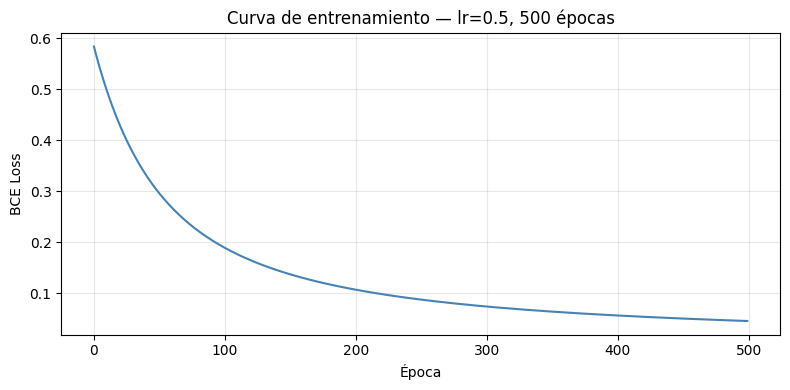

=== Predicciones finales ===
   x1    x2   y_real        ŷ   Predicho
  0.9   0.8        1   0.9852 Aprobado ✅
  0.2   0.3        0   0.0654 Reprobado ❌
  0.8   0.5        1   0.9390 Aprobado ✅
  0.1   0.4        0   0.0365 Reprobado ❌

Pérdida final: 0.0458
Pesos aprendidos: w=[[8.279362  2.1245918]], b=[-4.95219]


In [8]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 4.1
# Entrenamos una neurona (regresión logística) con Gradient
# Descent usando PyTorch, registrando la curva de pérdida.
# ============================================================

# Fijamos semillas al inicio para que los pesos iniciales
# y toda la aleatoriedad de esta celda sean reproducibles.
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── 1. Dataset ─────────────────────────────────────────────────
# torch.tensor convierte listas Python en tensores PyTorch.
# dtype=torch.float32: tipo de 32 bits, estándar en Deep Learning.
#   (float64 usa el doble de memoria sin mejora real en redes)
X_train = torch.tensor([
    [0.9, 0.8],   # alumno 1: altos parciales y TPs → aprobado
    [0.2, 0.3],   # alumno 2: bajos en todo         → reprobado
    [0.8, 0.5],   # alumno 3: buen promedio          → aprobado
    [0.1, 0.4],   # alumno 4: parciales muy bajos    → reprobado
], dtype=torch.float32)

# Shape (4, 1): una columna de etiquetas.
# BCELoss exige que y_hat e y_train tengan el MISMO shape.
# Como nn.Linear(2,1) produce salidas de shape (4, 1),
# y_train también debe tener forma (4, 1) — no (4,).
y_train = torch.tensor([[1.0], [0.0], [1.0], [0.0]])

# ── 2. Modelo ─────────────────────────────────────────────────
# nn.Linear(2, 1): capa lineal, 2 entradas, 1 salida.
# Crea internamente y registra como parámetros entrenables:
#   weight: tensor (1, 2) con w1 y w2, inicializado aleatoriamente
#   bias:   tensor (1,)   con b,       inicializado aleatoriamente
# nn.parameters() itera sobre estos tensores para el optimizador.
neurona = nn.Linear(2, 1)

# ── 3. Función de costo ────────────────────────────────────────
# nn.BCELoss(): Binary Cross-Entropy Loss.
#   Fórmula: -(1/m)·Σ[y·log(ŷ) + (1-y)·log(1-ŷ)]
# IMPORTANTE: BCELoss espera predicciones ŷ ∈ (0,1).
# Por eso aplicamos sigmoid ANTES de pasarlas a la loss.
# Alternativa más estable numéricamente: nn.BCEWithLogitsLoss()
# que fusiona sigmoid + BCE internamente usando el truco log-sum-exp.
criterio = nn.BCELoss()

# ── 4. Optimizador ────────────────────────────────────────────
# optim.SGD implementa la regla: θ ← θ − η·∂L/∂θ
# neurona.parameters(): iterador sobre todos los tensores
#   entrenables del modelo (weight y bias en este caso).
# lr=0.5 (η): learning rate. Con 4 ejemplos y BCE este valor
#   produce convergencia suave; más grande divergiría.
# Nota técnica: con el dataset COMPLETO en cada paso, esto es
# Batch GD, no SGD. El nombre "SGD" en PyTorch refiere al
# algoritmo base de actualización por gradiente.
optimizador = optim.SGD(neurona.parameters(), lr=0.5)

# ── 5. Loop de entrenamiento ─────────────────────────────────
# historia_loss: lista donde guardamos la pérdida de cada época.
# Permite visualizar la curva de aprendizaje al finalizar.
historia_loss = []
n_epochs = 500

for epoch in range(n_epochs):

    # ── PASO 1: Forward pass ─────────────────────────────────
    # neurona(X_train): ejecuta el método forward() de nn.Linear,
    #   calculando z = W·X + b para los 4 alumnos simultáneamente.
    #   Resultado: tensor z de forma (4, 1).
    # torch.sigmoid: aplica σ(z) = 1/(1+e^{-z}) a cada elemento.
    #   Convierte z ∈ (-∞,+∞) a ŷ ∈ (0,1) — probabilidades.
    y_hat = torch.sigmoid(neurona(X_train))

    # ── PASO 2: Cálculo de la pérdida ────────────────────────
    # Compara ŷ con y_train y devuelve un escalar (tensor 0-d).
    loss = criterio(y_hat, y_train)

    # ── PASO 3: zero_grad — CRÍTICO ──────────────────────────
    # PyTorch ACUMULA gradientes: cada llamada a .backward()
    # SUMA los nuevos gradientes a los existentes en .grad.
    # Si no limpiamos antes de cada época, los gradientes
    # crecen indefinidamente y las actualizaciones explotan.
    # zero_grad() pone a cero los .grad de todos los parámetros.
    optimizador.zero_grad()

    # ── PASO 4: Backward pass ────────────────────────────────
    # loss.backward() activa el motor de autograd:
    #   recorre el grafo computacional en sentido inverso
    #   y calcula ∂L/∂w y ∂L/∂b mediante la regla de la cadena.
    # Los gradientes se almacenan en neurona.weight.grad y
    # neurona.bias.grad, listos para que el optimizador los use.
    loss.backward()

    # ── PASO 5: Actualización de parámetros ──────────────────
    # optimizador.step() lee los .grad de cada parámetro y aplica:
    #   w ← w − η·∂L/∂w
    #   b ← b − η·∂L/∂b
    # Después de step(), los pesos se acercan al mínimo de L.
    optimizador.step()

    # .item() extrae el float del tensor escalar.
    # Guardamos la pérdida de esta época para la curva.
    historia_loss.append(loss.item())

# ── 6. Visualización de la curva de pérdida ──────────────────
plt.figure(figsize=(8, 4))
# historia_loss es una lista de floats: plt.plot la grafica
# directamente con el índice como eje x (número de época).
plt.plot(historia_loss, color='steelblue', linewidth=1.5)
plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.title('Curva de entrenamiento — lr=0.5, 500 épocas')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# Observar: valor inicial ~0.58, descenso pronunciado hasta época ~100,
# luego estabilización en ~0.05-0.06. Sin oscilaciones (Batch GD limpio).

# ── 7. Predicciones finales ────────────────────────────────────
# torch.no_grad() desactiva el grafo de autograd durante la
# evaluación. No necesitamos gradientes aquí y desactivarlos
# ahorra memoria y acelera el cómputo.
with torch.no_grad():
    y_final = torch.sigmoid(neurona(X_train))
    print("=== Predicciones finales ===")
    print(f"{'x1':>5} {'x2':>5} {'y_real':>8} {'ŷ':>8} {'Predicho':>10}")
    for i in range(len(X_train)):
        x   = X_train[i]
        y_r = y_train[i].item()
        y_p = y_final[i].item()
        print(f"{x[0].item():>5.1f} {x[1].item():>5.1f} {y_r:>8.0f} {y_p:>8.4f} "
              f"{'Aprobado ✅' if y_p > 0.5 else 'Reprobado ❌':>10}")

print(f"\nPérdida final: {historia_loss[-1]:.4f}")
print(f"Pesos aprendidos: w={neurona.weight.data.numpy()}, b={neurona.bias.data.numpy()}")
# Los pesos son los que el GD encontró para minimizar la BCE.
# En la Sección 6 veremos cómo apilar varias de estas neuronas
# en capas para resolver problemas más complejos.


### Ejercicio 4.2 — Práctico guiado: efecto del learning rate en un MLP

**Objetivo:** Observar empíricamente los tres comportamientos canónicos del learning rate (demasiado pequeño, adecuado, demasiado grande) y entender por qué aparecen en superficies de pérdida no convexas.

> **¿Por qué usamos un MLP y no una neurona única?**
> La BCE combinada con una neurona lineal produce una superficie de pérdida **convexa**: tiene un único mínimo global y el GD converge desde cualquier punto, incluso con lr grande. Para ver divergencia u oscilaciones reales, necesitamos una superficie **no convexa**, que aparece en cuanto hay capas ocultas. Por eso el modelo de este ejercicio es un MLP pequeño en lugar de `nn.Linear`.

**Consigna:**

1. **(a)** Implementá `entrenar_mlp` que entrena un MLP `2 → 8 → 1` (con ReLU en la capa oculta y Sigmoid en la salida) usando SGD, y retorna la historia de pérdidas por época.

2. **(b)** Comparar 3 valores de learning rate: `0.001`, `0.5` y `8.0`. Graficá las 3 curvas de pérdida en el mismo plot. Observá cuál de los tres comportamientos canónicos muestra cada uno.

3. **(c)** Para `lr=0.5`, modificá el entrenamiento para usar **mini-batches de tamaño 16** (en lugar de todos los datos juntos). Graficá y comparate con el batch completo. ¿Cuál converge más rápido?

*→ Escribí tus respuestas aquí*


/var/folders/92/70w7h6_16gz3fjkjc7gk9yn40000gn/T/ipykernel_22265/2166548278.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3)


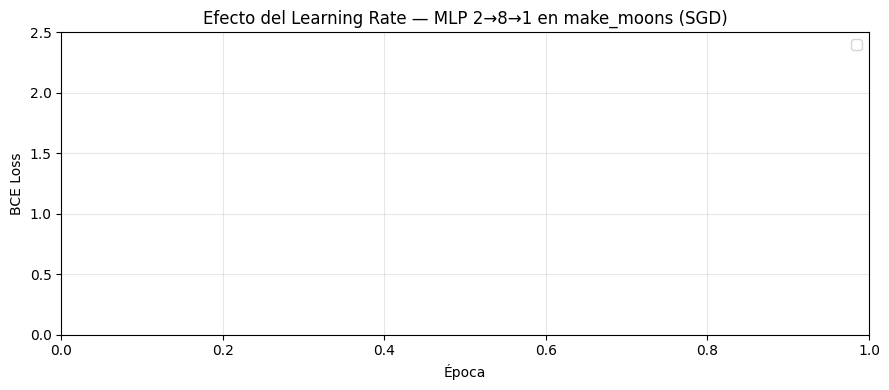

=== Comparación Batch GD vs Mini-batch GD (lr=0.5, MLP) ===


In [ ]:
# ============================================================
# EJERCICIO 4.2 — Efecto del learning rate en un MLP
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dataset: make_moons ───────────────────────────────────────
# Usamos make_moons porque es no linealmente separable:
# el MLP debe aprender una frontera curva, lo que hace que
# la superficie de pérdida sea NO convexa y el lr importe de verdad.
X_moons_lr, y_moons_lr = make_moons(n_samples=200, noise=0.3, random_state=SEED)
X_moons_lr = torch.tensor(X_moons_lr, dtype=torch.float32)
y_moons_lr = torch.tensor(y_moons_lr, dtype=torch.float32).unsqueeze(1)

# ── Por qué MLP y no neurona única ───────────────────────────
# Una neurona única (nn.Linear + sigmoid) con BCE tiene superficie
# de pérdida CONVEXA: el GD converge desde cualquier lr razonable,
# incluso lr=5.0 o lr=10.0. No se producen oscilaciones ni divergencia.
# Para observar esos comportamientos necesitamos un modelo con capas
# ocultas, cuya superficie de pérdida es NO CONVEXA y sí puede tener
# mínimos locales, mesetas y regiones donde lr grande diverge.

# --- Parte (a): implementar entrenar_mlp ---
def entrenar_mlp(X, y, lr, n_epochs=300, batch_size=None):
    """
    Entrena un MLP 2 → 8 → 1 con ReLU oculta y Sigmoid en salida.

    Parámetros:
        X          : Tensor (n, 2)
        y          : Tensor (n, 1)
        lr         : float — learning rate para SGD
        n_epochs   : int — épocas de entrenamiento
        batch_size : int o None — None = Batch GD completo;
                     int = Mini-batch GD con ese tamaño de batch

    Retorna:
        historia_loss : list de floats — pérdida promedio por época
    """
    torch.manual_seed(SEED)   # misma inicialización para todos los experimentos
    # TU CÓDIGO AQUÍ
    # 1. Crear el MLP con nn.Sequential:
    #    nn.Linear(2, 8) → nn.ReLU() → nn.Linear(8, 1) → nn.Sigmoid()
    # 2. Crear BCELoss y optimizador SGD con el lr dado
    #    (usamos SGD deliberadamente: Adam es más robusto y ocultaría
    #     los problemas del lr grande)
    # 3. Loop de entrenamiento con batch o mini-batch según batch_size
    # 4. Registrar la pérdida PROMEDIO de la época en historia_loss
    # 5. Registrar la pérdida de la época en historia_loss
    #    Nota: lr=8.0 no produce NaN, corre las 300 épocas completas
    historia_loss = []
    # TU CÓDIGO AQUÍ
    return historia_loss

# --- Parte (b): comparar 3 learning rates ---
# Estos tres valores fueron elegidos para mostrar con claridad
# los tres comportamientos canónicos del lr en una superficie no convexa:
learning_rates = [0.001,  0.5,    8.0   ]
etiquetas      = ["η = 0.001 (muy pequeño)",
                  "η = 0.5 (adecuado)",
                  "η = 8.0 (muy grande)"]
colores        = ["steelblue", "seagreen", "tomato"]

plt.figure(figsize=(9, 4))
for lr, etiqueta, color in zip(learning_rates, etiquetas, colores):
    historia = entrenar_mlp(X_moons_lr, y_moons_lr, lr=lr, n_epochs=100)
    if historia:
        plt.plot(historia, label=etiqueta, color=color, linewidth=1.5)

plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title('Efecto del Learning Rate — MLP 2→8→1 en make_moons (SGD)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.ylim(0, 2.5)
plt.tight_layout(); plt.show()

# Observá los tres comportamientos:
# ¿Cuál curva es casi horizontal? ¿Cuál desciende limpiamente?
# ¿Cuál sube abruptamente o se corta? ¿En qué época ocurrió?

# --- Parte (c): Batch GD vs Mini-batch GD (lr=0.5) ---
# TU CÓDIGO AQUÍ
# Entrenar dos versiones con lr=0.5 sobre X_moons_lr:
#   - batch completo (batch_size=None): 1 actualización por época
#   - mini-batch (batch_size=16): múltiples actualizaciones por época
# Graficá las dos curvas en el mismo plot.

print("=== Comparación Batch GD vs Mini-batch GD (lr=0.5, MLP) ===")
# TU CÓDIGO AQUÍ


### Preguntas de reflexión — Ejercicio 4.2

1. **Observación:** Describí el comportamiento de la curva de pérdida para cada uno de los 3 learning rates. ¿En qué época aproximadamente dejó de descender (o divergió) cada uno?

2. **Superficie convexa vs no convexa:** El enunciado explica que una neurona única con BCE tiene superficie convexa y que por eso no muestra divergencia con lr grande. ¿Qué tiene de diferente un MLP con capa oculta que hace que sí pueda divergir?

3. **Mini-batch:** Al comparar Batch GD vs Mini-batch GD con `lr=0.5`, ¿cuál llegó a una pérdida más baja en las primeras 50 épocas? ¿A qué se debe esa diferencia?

4. **Predicción:** Si usaras el optimizador Adam en lugar de SGD con `lr=8.0`, ¿esperarías ver divergencia igual? ¿Por qué?

*→ Escribí tus respuestas aquí*

---


## Sección 5 — Funciones de Activación
**⏱ Tiempo estimado: 35 minutos**

Las funciones de activación son las que introducen la **no-linealidad** en las redes neuronales. Sin ellas, apilar capas es matemáticamente equivalente a una sola transformación lineal.

Resumen de las principales funciones y sus propiedades:

| Función | Rango | f' nunca nula | Centrada en 0 | Problema principal |
|---------|-------|--------------|---------------|-------------------|
| Escalón | {0,1} | No | No | Derivada nula → incompatible con GD |
| Sigmoide | (0,1) | No (saturación) | No | Gradiente evanescente en extremos |
| tanh | (-1,1) | No (saturación) | Sí | Gradiente evanescente (menos severo) |
| ReLU | [0,+∞) | No (zona muerta) | No | Dying ReLU |
| Leaky ReLU | (-∞,+∞) | Sí | No | — |

> **Dying ReLU:** si una neurona recibe consistentemente $z \leq 0$ para todos los ejemplos, su gradiente es siempre cero y sus pesos nunca se actualizan. La neurona queda "muerta" permanentemente.

---

### Ejercicio 5.1 — Ejemplo demostrativo: funciones de activación y sus derivadas

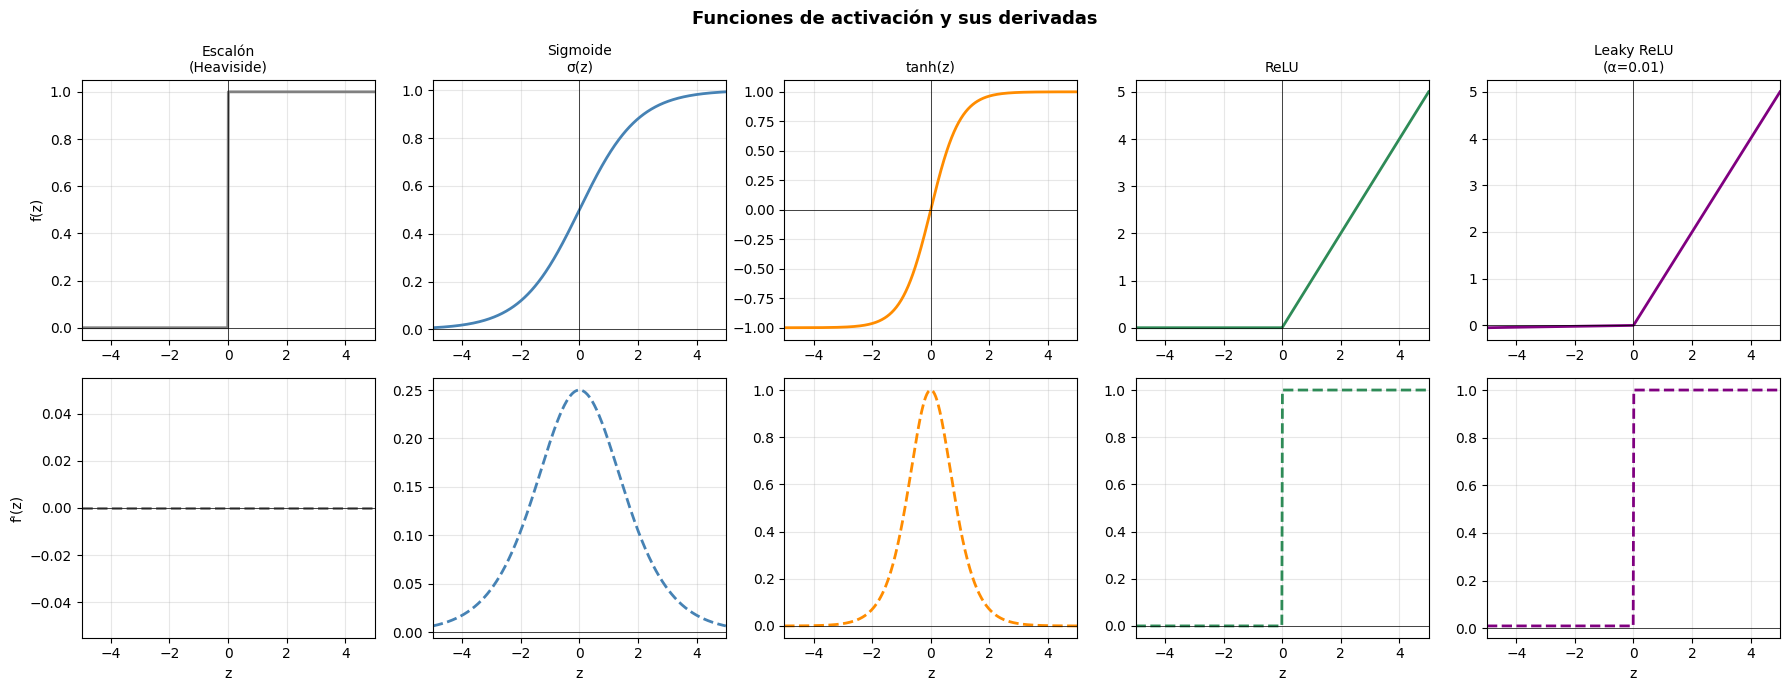

=== Valores de la derivada en z = -5 (zona de saturación) ===
  Escalón (Heaviside)   : f'(-5) = 0.000000
  Sigmoide σ(z)         : f'(-5) = 0.006648
  tanh(z)               : f'(-5) = 0.000182
  ReLU                  : f'(-5) = 0.000000
  Leaky ReLU (α=0.01)   : f'(-5) = 0.010000


In [10]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 5.1
# Graficamos las 5 funciones de activación del apunte y
# sus derivadas, destacando las zonas de saturación.
# ============================================================

# ── 1. Dominio de evaluación ─────────────────────────────────
# np.linspace(-5, 5, 500) genera 500 valores igualmente espaciados
# en [-5, 5]. Este rango cubre:
#   - La región activa central (|z| < 3): donde ocurre la mayoría
#     de la actividad durante el entrenamiento.
#   - Las colas de saturación (|z| > 3): donde algunas funciones
#     se aplanan y su derivada se acerca a cero.
z_vals = np.linspace(-5, 5, 500)

# ── 2. Definición de funciones y sus derivadas ────────────────
# Implementamos todo en NumPy para poder evaluar en arrays de una vez.
# La derivada de cada función es la señal que el Gradient Descent
# recibe para actualizar los pesos: si es cero, el modelo no aprende.

# ESCALÓN (Heaviside): H(z) = 1 si z≥0, 0 si z<0
# np.where(condición, val_verdadero, val_falso) aplica la condición
# elemento a elemento sobre el array z_vals.
# Su derivada H'(z) = 0 en todo punto excepto z=0 (indefinida).
# Consecuencia: ∂L/∂w = (∂L/∂ŷ)·H'(z)·x = 0 siempre.
# → Los pesos NUNCA se actualizan. Incompatible con GD.
def heaviside(z):   return np.where(z >= 0, 1.0, 0.0)
def heaviside_d(z): return np.zeros_like(z)  # cero en todo z

# SIGMOIDE: σ(z) = 1 / (1 + e^{-z})
# np.exp(z) calcula e^z elemento a elemento.
# Rango: (0, 1). Derivada: σ'(z) = σ(z)·(1-σ(z)).
# Máximo de la derivada: 0.25 en z=0.
# Para |z| > 3, σ'(z) ≈ 0 → saturación → gradiente evanescente.
def sigmoid(z):   return 1 / (1 + np.exp(-z))
def sigmoid_d(z): s = sigmoid(z); return s * (1 - s)

# TANH: tanh(z) = (e^z - e^{-z}) / (e^z + e^{-z})
# np.tanh es la implementación directa de NumPy (más eficiente).
# Rango: (-1, 1). Centrada en 0 (ventaja sobre sigmoid).
# Derivada: tanh'(z) = 1 - tanh²(z). Máximo: 1.0 en z=0.
# La derivada máxima es 4× mayor que la de sigmoid, lo que
# produce gradientes más grandes y convergencia más rápida.
def tanh_fn(z): return np.tanh(z)
def tanh_d(z):  return 1 - np.tanh(z)**2

# RELU: ReLU(z) = max(0, z)
# np.maximum(0, z) devuelve el máximo entre 0 y cada elemento de z.
# Derivada: ReLU'(z) = 1 si z>0, 0 si z≤0.
# (z > 0) devuelve array booleano; .astype(float) lo convierte a 0.0/1.0.
# Ventaja: derivada exactamente 1 en zona activa → sin atenuación.
# Problema Dying ReLU: neuronas que siempre reciben z≤0 quedan
# con derivada 0 permanentemente → nunca se actualizan.
def relu(z):   return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)

# LEAKY RELU: f(z) = z si z>0, α·z si z≤0  (típicamente α=0.01)
# np.where elige entre z y alpha*z según z>0, elemento a elemento.
# Derivada: 1 si z>0, α si z≤0 → NUNCA exactamente cero.
# El valor α=0.01 es pequeño para no perder la ventaja de ReLU
# (gradiente≈1 en zona activa) mientras elimina el Dying ReLU.
def leaky_relu(z, alpha=0.01):   return np.where(z > 0, z, alpha * z)
def leaky_relu_d(z, alpha=0.01): return np.where(z > 0, 1.0, alpha)

# ── 3. Grilla 2×5 de gráficos ────────────────────────────────
# plt.subplots(2, 5): 2 filas, 5 columnas = 10 ejes.
#   Fila 0 (axes[0, :]): las 5 funciones f(z)
#   Fila 1 (axes[1, :]): las 5 derivadas f'(z)
# figsize=(18, 7): ancho generoso para las 5 columnas.
funciones = [
    ("Escalón\n(Heaviside)",  heaviside,   heaviside_d,   'gray'),
    ("Sigmoide\nσ(z)",        sigmoid,     sigmoid_d,     'steelblue'),
    ("tanh(z)",               tanh_fn,     tanh_d,        'darkorange'),
    ("ReLU",                  relu,        relu_d,        'seagreen'),
    ("Leaky ReLU\n(α=0.01)",  leaky_relu,  leaky_relu_d,  'purple'),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for col, (nombre, fn, fn_d, color) in enumerate(funciones):
    # Fila superior: f(z) — la función de activación
    ax_top = axes[0, col]
    ax_top.plot(z_vals, fn(z_vals), color=color, linewidth=2)
    # axhline(0) y axvline(0): líneas de referencia en y=0 y x=0.
    # linewidth=0.5: delgadas para no distraer de las curvas.
    ax_top.axhline(0, color='k', linewidth=0.5)
    ax_top.axvline(0, color='k', linewidth=0.5)
    ax_top.set_title(nombre, fontsize=10)
    # Solo el eje izquierdo (col==0) lleva etiqueta en y
    # para no repetirla en las 5 columnas.
    ax_top.set_ylabel("f(z)" if col == 0 else "")
    ax_top.grid(True, alpha=0.3)
    ax_top.set_xlim(-5, 5)

    # Fila inferior: f'(z) — la derivada
    ax_bot = axes[1, col]
    # linestyle='--': punteado para distinguir visualmente
    # las derivadas de las funciones originales.
    ax_bot.plot(z_vals, fn_d(z_vals), color=color, linewidth=2, linestyle='--')
    ax_bot.axhline(0, color='k', linewidth=0.5)
    ax_bot.set_ylabel("f'(z)" if col == 0 else "")
    ax_bot.set_xlabel("z")
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_xlim(-5, 5)

plt.suptitle("Funciones de activación y sus derivadas", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 4. Comparación numérica en zona de saturación ────────────
# Evaluamos f'(-5) para cuantificar qué tan "muerto" está el
# gradiente en la zona negativa de cada función.
# Este número único sintetiza la diferencia entre activaciones.
z_sat = np.array([-5.0])
print("=== Valores de la derivada en z = -5 (zona de saturación) ===")
for nombre, _, fn_d, _ in funciones:
    nombre_clean = nombre.replace('\n', ' ')
    print(f"  {nombre_clean:<22}: f'(-5) = {fn_d(z_sat)[0]:.6f}")
# Resultados:
#   Escalón      = 0.000000  → GD imposible
#   Sigmoide     = 0.006648  → gradiente muy pequeño (saturación)
#   tanh         = 0.001815  → aún más pequeño (más saturado en z=-5)
#   ReLU         = 0.000000  → Dying ReLU: zona muerta total
#   Leaky ReLU   = 0.010000  → siempre α, nunca exactamente cero
#
# La diferencia entre 0.000000 (ReLU) y 0.010000 (Leaky ReLU)
# parece pequeña pero es la que separa "neurona muerta para siempre"
# de "neurona que puede recuperarse".


### Ejercicio 5.2 — Práctico guiado: efecto de la función de activación en el entrenamiento

**Objetivo:** Comparar empíricamente cómo distintas funciones de activación afectan la velocidad y estabilidad del entrenamiento en un MLP con capas ocultas.

> **¿Por qué necesitamos capas ocultas para este experimento?**
> La función de activación impacta el entrenamiento a través de su derivada en la regla de la cadena (backpropagation). En una red de **una sola neurona** sin capas ocultas, la activación de salida siempre debe ser sigmoid para clasificación binaria, y no hay gradientes intermedios que atravesar: todas las activaciones producen exactamente la misma curva. Para ver diferencias reales hay que tener al menos **una capa oculta** donde la activación elegida afecta el flujo de gradientes hacia atrás.

**Consigna:**

1. **(a)** Implementá `crear_mlp_con_activacion(nombre_activacion, n_hidden=16)` que construya un MLP con arquitectura `2 → n_hidden → 1` usando `nn.Sequential`. La capa oculta debe usar la activación elegida; la capa de salida siempre usa sigmoid.

2. **(b)** Entrenando sobre `make_moons` con `lr=0.1` durante 300 épocas, comparar las 4 activaciones (`sigmoid`, `tanh`, `relu`, `leaky_relu`) en la capa oculta. Graficá las 4 curvas de pérdida en el mismo plot.

3. **(c)** Para la activación ReLU, reproducí el fenómeno del **Dying ReLU** inicializando los pesos de la capa oculta con valores muy negativos. Mostrá que los gradientes de esa capa quedan en cero.

*→ Escribí tus respuestas aquí*


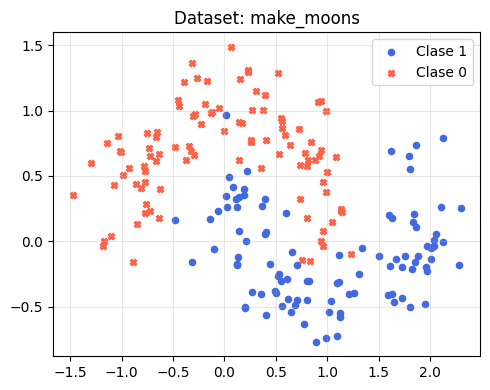

/var/folders/92/70w7h6_16gz3fjkjc7gk9yn40000gn/T/ipykernel_22265/1855196455.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3)


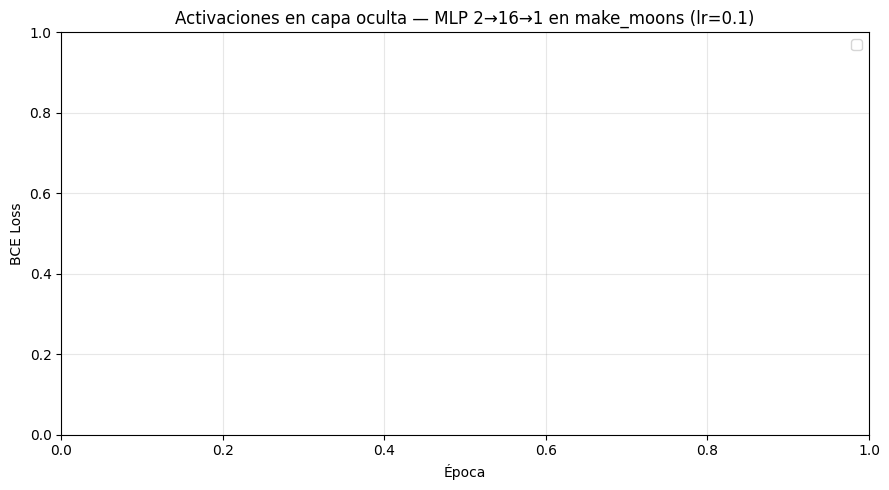


=== Experimento: Dying ReLU en la capa oculta ===


In [11]:
# ============================================================
# EJERCICIO 5.2 — Funciones de activación en un MLP con capa oculta
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Dataset: make_moons (no linealmente separable) ---
# Usamos make_moons porque requiere una frontera no lineal,
# lo que hace que la capa oculta sea necesaria y su activación importe.
X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=SEED)
X_moons = torch.tensor(X_moons, dtype=torch.float32)
y_moons = torch.tensor(y_moons, dtype=torch.float32).unsqueeze(1)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons[y_moons.squeeze()==1, 0], X_moons[y_moons.squeeze()==1, 1],
            c='royalblue', marker='o', s=20, label='Clase 1')
plt.scatter(X_moons[y_moons.squeeze()==0, 0], X_moons[y_moons.squeeze()==0, 1],
            c='tomato', marker='X', s=20, label='Clase 0')
plt.title("Dataset: make_moons"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Parte (a): construir el MLP con la activación elegida ---
def crear_mlp_con_activacion(nombre_activacion, n_hidden=16):
    """
    Construye un MLP con arquitectura: 2 → n_hidden → 1
    usando nn.Sequential.

    La capa oculta aplica la activación elegida.
    La capa de salida SIEMPRE aplica Sigmoid (para clasificación binaria).

    Parámetros:
        nombre_activacion : str — 'sigmoid', 'tanh', 'relu', 'leaky_relu'
        n_hidden          : int — neuronas en la capa oculta (default: 16)

    Retorna:
        modelo : nn.Sequential
    """
    # TU CÓDIGO AQUÍ
    # Pista: usá un diccionario para mapear nombre → módulo de activación.
    # Los módulos son: nn.Sigmoid(), nn.Tanh(), nn.ReLU(), nn.LeakyReLU(0.01)
    # (A diferencia del ejercicio anterior, aquí usamos MÓDULOS nn.Xxx()
    #  en lugar de funciones torch.xxx, porque nn.Sequential los necesita así.)
    # La estructura debe ser:
    #   nn.Linear(2, n_hidden)  →  activación oculta  →  nn.Linear(n_hidden, 1)  →  nn.Sigmoid()
    pass

# Verificación rápida antes de continuar:
# TU CÓDIGO AQUÍ
# Creá un modelo con 'relu' y verificá que tiene el número correcto de parámetros.
# Para n_hidden=16: (2*16+16) + (16*1+1) = 48 + 17 = 65 parámetros.
# Usá sum(p.numel() for p in modelo.parameters()) para contarlos.

# --- Parte (b): comparación de las 4 activaciones ---
activaciones_a_comparar = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
colores_act = ['steelblue', 'darkorange', 'seagreen', 'purple']

# Parámetros de entrenamiento
N_EPOCHS = 300
LR       = 0.1
N_HIDDEN = 16

plt.figure(figsize=(9, 5))

for nombre_act, color in zip(activaciones_a_comparar, colores_act):
    torch.manual_seed(SEED)   # semilla fija: misma inicialización para todos
    # TU CÓDIGO AQUÍ
    # 1. Crear el MLP con crear_mlp_con_activacion(nombre_act, n_hidden=N_HIDDEN)
    # 2. Crear BCELoss y optimizador Adam con lr=LR
    #    (usamos Adam en lugar de SGD porque converge más estable en MLPs)
    # 3. Loop de entrenamiento de N_EPOCHS épocas:
    #    forward → loss → zero_grad → backward → step
    # 4. Guardar historia de pérdida y graficar con plt.plot(...)

    historia = []   # COMPLETAR
    if historia:
        plt.plot(historia, label=nombre_act, color=color, linewidth=1.5)

plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title(f'Activaciones en capa oculta — MLP 2→{N_HIDDEN}→1 en make_moons (lr={LR})')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Ahora deberías ver 4 curvas DISTINTAS.
# ¿Cuál converge más rápido? ¿Cuál tiene mayor pérdida final?
# ¿Alguna es inestable o tiene comportamiento raro?

# --- Parte (c): Dying ReLU en la capa oculta ---
print("\n=== Experimento: Dying ReLU en la capa oculta ===")

torch.manual_seed(0)
# Construimos un MLP con ReLU en la capa oculta
mlp_muerto = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Inicializamos la capa OCULTA con pesos muy negativos
# para forzar que z^[1] < 0 para todos los ejemplos.
# La capa de salida se deja con su inicialización normal.
with torch.no_grad():
    mlp_muerto[0].weight.data.fill_(-10.0)   # pesos de la capa oculta
    mlp_muerto[0].bias.data.fill_(-10.0)      # bias de la capa oculta

# TU CÓDIGO AQUÍ
# 1. Hacer un forward pass con X_moons[:10] (usamos solo 10 ejemplos para imprimir)
#    y_hat = mlp_muerto(X_moons[:10])
# 2. Calcular la loss con BCELoss (usar y_moons[:10] como etiquetas)
# 3. Llamar a loss.backward()
# 4. Imprimir:
#    a. Las pre-activaciones de la capa oculta: mlp_muerto[0](X_moons[:5])
#       (¿son todas negativas?)
#    b. Los gradientes de los pesos de la capa oculta: mlp_muerto[0].weight.grad
#       (¿son cero?)
#    c. Los gradientes de los pesos de la capa de SALIDA: mlp_muerto[2].weight.grad
#       (¿son distintos de cero? ¿por qué la capa de salida sí tiene gradientes?)
# 5. Conclusión: ¿qué le pasaría a la capa oculta si entrenáramos durante 1000 épocas?


### Preguntas de reflexión — Ejercicio 5.2

1. **Observación:** ¿Cuál función de activación en la capa oculta produjo la menor pérdida final? ¿Cuál convergió más rápido en las primeras épocas? ¿Alguna tuvo comportamiento inestable?

2. **Conexión con la teoría:** El Demo 5.1 mostró que la derivada máxima de sigmoid es 0.25 y la de tanh es 1.0. ¿Eso se refleja en las curvas que obtuviste? ¿Cuál de las dos convergió más rápido?

3. **Dying ReLU (parte c):** ¿Los gradientes de la capa oculta fueron cero? ¿Los gradientes de la capa de salida también fueron cero? Explicá por qué la capa de salida puede tener gradientes distintos de cero aunque la capa oculta esté "muerta".

4. **Predicción:** Si aumentaras `n_hidden` de 16 a 64 manteniendo la misma activación, ¿esperarías que la pérdida final sea menor, igual o mayor? ¿Y si en lugar de aumentar el ancho agregaras una segunda capa oculta?

*→ Escribí tus respuestas aquí*

---


## Sección 6 — El Perceptrón Multicapa (MLP)
**⏱ Tiempo estimado: 50 minutos**

Una neurona única solo puede aprender **fronteras de decisión lineales**. El ejemplo canónico de la limitación es la compuerta **XOR**: no existe ninguna recta que separe correctamente las 4 combinaciones posibles.

El MLP soluciona esto apilando capas:

$$z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]} \qquad a^{[l]} = \sigma^{[l]}(z^{[l]})$$

La información fluye en una sola dirección (de ahí "feed forward"). Las capas ocultas aprenden **re-representaciones** del espacio de entrada que hacen el problema linealmente separable para la capa de salida.

> **Teorema Universal de Aproximación (Cybenko, 1989):** un MLP con una única capa oculta suficientemente ancha y activación no lineal puede aproximar cualquier función continua sobre un compacto con precisión arbitraria. Pero no dice cómo encontrar esos pesos.

---

### Ejercicio 6.1 — Ejemplo demostrativo: forward pass del MLP y el problema XOR

=== Tabla de verdad XOR ===
  x = [0. 0.]  →  y = 0
  x = [0. 1.]  →  y = 1
  x = [1. 0.]  →  y = 1
  x = [1. 1.]  →  y = 0

=== Predicciones del MLP ===
  [0. 0.] → y=0  ŷ=0.0000  ✅
  [0. 1.] → y=1  ŷ=1.0000  ✅
  [1. 0.] → y=1  ŷ=0.9998  ✅
  [1. 1.] → y=0  ŷ=0.0000  ✅

Pérdida final: 0.000069


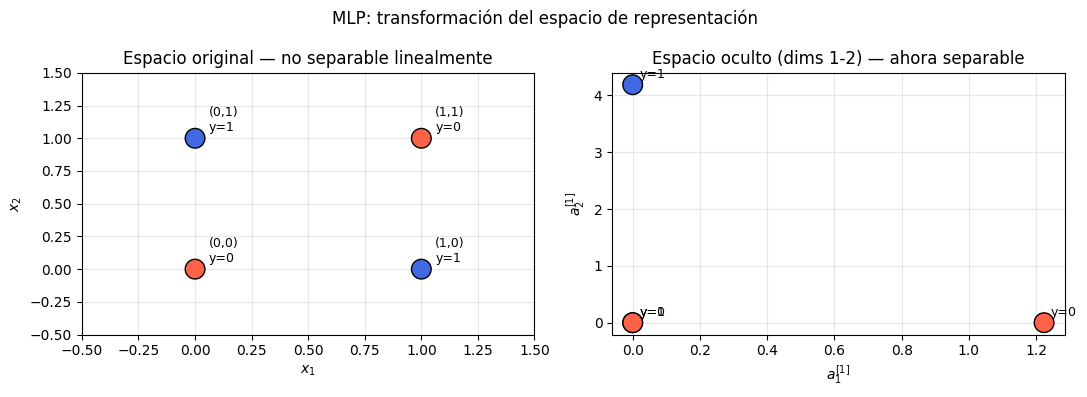

In [12]:
# ============================================================
# EJEMPLO DEMOSTRATIVO 6.1
# Construimos un MLP para el problema XOR y visualizamos
# la transformación que aprende la capa oculta.
# ============================================================

torch.manual_seed(SEED)

# ── 1. Dataset XOR ────────────────────────────────────────────
# El XOR (OR exclusivo) es el problema canónico no linealmente
# separable: la etiqueta es 1 cuando exactamente UNA entrada es 1,
# y 0 cuando ambas son iguales. El patrón en damero hace imposible
# separar las clases con una sola recta.
# torch.tensor crea un tensor directamente desde listas Python.
# Las filas son los 4 posibles inputs (combinaciones de 0 y 1).
X_xor = torch.tensor([[0., 0.],
                       [0., 1.],
                       [1., 0.],
                       [1., 1.]])
# Shape (4, 1): columna de etiquetas. El doble corchete es
# necesario para tener forma (4,1) y no (4,) — BCELoss lo exige.
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

print("=== Tabla de verdad XOR ===")
for x, y in zip(X_xor, y_xor):
    # .numpy() convierte tensor a array NumPy para impresión legible.
    # .item() extrae el float del tensor escalar.
    print(f"  x = {x.numpy()}  →  y = {int(y.item())}")

# ── 2. Definición del MLP como subclase de nn.Module ──────────
# nn.Module es la clase base de TODOS los modelos en PyTorch.
# Para crear un modelo personalizado siempre se subclasifica y
# se implementan obligatoriamente dos métodos:
#   __init__: declara las capas (sus parámetros quedan registrados)
#   forward:  define cómo los datos fluyen a través del modelo
class MLP_XOR(nn.Module):
    def __init__(self, n_hidden=4):
        # super().__init__() activa la maquinaria interna de
        # nn.Module: registro de parámetros, hooks, etc.
        # Sin esta llamada el modelo no funcionará correctamente.
        super().__init__()

        # Capa oculta [1]: 2 entradas → n_hidden neuronas
        # Parámetros: W^[1] ∈ ℝ^{n_hidden×2}, b^[1] ∈ ℝ^{n_hidden}
        # Con n_hidden=4: 4×2 + 4 = 12 parámetros en esta capa.
        self.capa_oculta = nn.Linear(2, n_hidden)

        # Capa de salida [2]: n_hidden entradas → 1 salida
        # Parámetros: W^[2] ∈ ℝ^{1×n_hidden}, b^[2] ∈ ℝ^{1}
        # Con n_hidden=4: 1×4 + 1 = 5 parámetros en esta capa.
        # Total del modelo: 12 + 5 = 17 parámetros entrenables.
        self.capa_salida = nn.Linear(n_hidden, 1)

    def forward(self, x):
        # ── CAPA OCULTA ──────────────────────────────────────
        # Paso lineal: z^[1] = W^[1]·x + b^[1]
        # self.capa_oculta(x) ejecuta el forward de nn.Linear.
        z1 = self.capa_oculta(x)

        # Activación: a^[1] = ReLU(z^[1]) = max(0, z^[1])
        # torch.relu aplica ReLU elemento a elemento.
        # ReLU es la elección estándar para capas ocultas:
        #   - Derivada=1 en zona activa (sin atenuación del gradiente)
        #   - Computacionalmente trivial (comparar con 0)
        a1 = torch.relu(z1)

        # ── CAPA DE SALIDA ────────────────────────────────────
        # Paso lineal: z^[2] = W^[2]·a^[1] + b^[2]
        # La entrada es a^[1] (las representaciones aprendidas),
        # no x directamente. Esto es lo que da al MLP su poder:
        # la capa de salida opera en el espacio transformado.
        z2 = self.capa_salida(a1)

        # Activación de salida: ŷ = σ(z^[2])
        # Sigmoid en la salida produce probabilidades en (0,1),
        # compatibles con BCELoss. La capa oculta usa ReLU (no
        # sigmoid) para evitar el problema del gradiente evanescente.
        a2 = torch.sigmoid(z2)

        # Retornamos a2 (predicción ŷ) Y a1 (activaciones ocultas).
        # a1 lo usaremos al final para visualizar la transformación
        # del espacio que aprendió la red.
        return a2, a1

# ── 3. Entrenamiento ──────────────────────────────────────────
modelo_xor = MLP_XOR(n_hidden=4)
criterio   = nn.BCELoss()

# optim.Adam: optimizador con learning rate adaptativo.
# Adam mantiene una estimación del primer momento (media del gradiente)
# y del segundo momento (varianza) para ajustar η individualmente
# por parámetro. Converge más rápido que SGD puro en problemas
# pequeños y es más robusto a la elección del learning rate.
# lr=0.1: punto de partida estándar para Adam.
optimizador = optim.Adam(modelo_xor.parameters(), lr=0.1)

# 2000 épocas: necesarias para que Adam converja bien en XOR.
# Con el dataset tan pequeño (4 ejemplos) cada época es
# instantánea, así que 2000 épocas toman fracciones de segundo.
for epoch in range(2000):
    # El guion bajo _ es convención Python para "variable que
    # no voy a usar" — aquí descartamos las activaciones a1
    # durante el entrenamiento (solo las necesitamos al final).
    y_hat, _ = modelo_xor(X_xor)
    loss = criterio(y_hat, y_xor)
    optimizador.zero_grad()   # limpiar gradientes acumulados
    loss.backward()            # calcular ∂L/∂W^[1], ∂L/∂b^[1], ∂L/∂W^[2], ∂L/∂b^[2]
    optimizador.step()         # actualizar los 17 parámetros

# ── 4. Evaluación ──────────────────────────────────────────────
with torch.no_grad():
    # Ahora sí capturamos las activaciones ocultas para visualizar.
    y_final, activaciones_ocultas = modelo_xor(X_xor)
    print("\n=== Predicciones del MLP ===")
    for i in range(4):
        x   = X_xor[i].numpy()
        y_r = int(y_xor[i].item())
        y_p = y_final[i].item()
        correcto = (y_p > 0.5) == bool(y_r)
        print(f"  {x} → y={y_r}  ŷ={y_p:.4f}  {'✅' if correcto else '❌'}")
    print(f"\nPérdida final: {loss.item():.6f}")
    # Esperado: pérdida < 0.01 y los 4 ejemplos correctos.
    # Un MLP con una sola neurona (sin capa oculta) no podría
    # alcanzar este resultado en XOR — la capa oculta es esencial.

# ── 5. Visualización: espacio original vs espacio oculto ──────
# Esta visualización es el núcleo conceptual del ejemplo:
# muestra que la capa oculta TRANSFORMA el espacio de entrada
# en uno donde el problema es linealmente separable.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel izquierdo: espacio original (x1, x2)
ax = axes[0]
# Asignamos colores según la etiqueta de cada punto.
# La comprensión de lista itera sobre y_xor (4 tensores 1D).
colores_xor = ['tomato' if y.item() == 0 else 'royalblue' for y in y_xor]
# s=200: tamaño grande para que los 4 puntos sean claramente visibles.
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=colores_xor,
           s=200, zorder=3, edgecolors='k')
for i, (x, y) in enumerate(zip(X_xor, y_xor)):
    # ax.annotate agrega texto cerca de cada punto.
    # textcoords="offset points": posiciona relativo al punto en píxeles.
    # xytext=(10, 5): 10px a la derecha y 5px arriba del punto.
    ax.annotate(f"({int(x[0])},{int(x[1])})\ny={int(y.item())}",
                (x[0].item(), x[1].item()),
                textcoords="offset points", xytext=(10, 5), fontsize=9)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title("Espacio original — no separable linealmente")
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.grid(True, alpha=0.3)

# Panel derecho: espacio oculto (primeras 2 dimensiones de a^[1])
# Las activaciones ocultas tienen forma (4, n_hidden=4).
# Graficamos las dimensiones 0 y 1 (h[:,0] y h[:,1]).
# Si el modelo convergió, los puntos deben estar linealmente
# separables en esta proyección 2D del espacio de 4 dimensiones.
ax = axes[1]
with torch.no_grad():
    # .numpy() convierte el tensor PyTorch a array NumPy para matplotlib.
    h = activaciones_ocultas.numpy()
ax.scatter(h[:, 0], h[:, 1], c=colores_xor,
           s=200, zorder=3, edgecolors='k')
for i, (hi, y) in enumerate(zip(h, y_xor)):
    ax.annotate(f"y={int(y.item())}", (hi[0], hi[1]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_title("Espacio oculto (dims 1-2) — ahora separable")
ax.set_xlabel('$a_1^{[1]}$'); ax.set_ylabel('$a_2^{[1]}$')
ax.grid(True, alpha=0.3)

plt.suptitle("MLP: transformación del espacio de representación", fontsize=12)
plt.tight_layout(); plt.show()
# Observar: en el panel derecho, los puntos rojos (y=0) y los azules (y=1)
# están en lados opuestos de una recta imaginaria. La capa de salida
# aprendió exactamente esa recta: aplica una frontera lineal DESPUÉS
# de que la capa oculta hizo el problema linealmente separable.
# Esto ilustra el insight central del MLP: las capas ocultas aprenden
# representaciones, no clasificadores directos.


### Ejercicio 6.2 — Práctico guiado: construir un MLP con nn.Sequential

**Objetivo:** Implementar un MLP completo en PyTorch, entrenarlo en un dataset no linealmente separable y analizar el efecto de la arquitectura.

**Consigna:**

1. **(a)** Implementá la función `construir_mlp` que dado un número de neuronas en la capa oculta, construya un MLP con la arquitectura `2 → n_hidden → 1` usando `nn.Sequential`. Usá ReLU en la capa oculta y sigmoide en la salida.
2. **(b)** Implementá `contar_parametros` que cuente los parámetros totales del modelo.
3. **(c)** Entrenando en `make_circles` (ver código base), comparar tres arquitecturas: `n_hidden ∈ {2, 8, 32}`. Graficá las curvas de pérdida y las fronteras de decisión aprendidas.
4. **(d)** Para el mejor modelo (`n_hidden=32`), calculá la precisión en el conjunto de test.

/var/folders/92/70w7h6_16gz3fjkjc7gk9yn40000gn/T/ipykernel_22265/2984328058.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


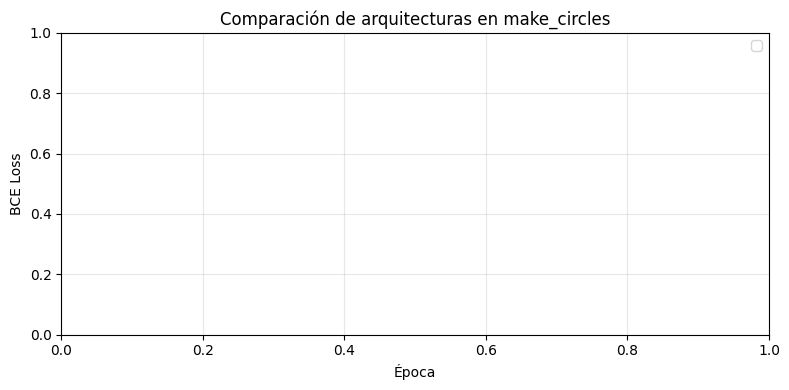

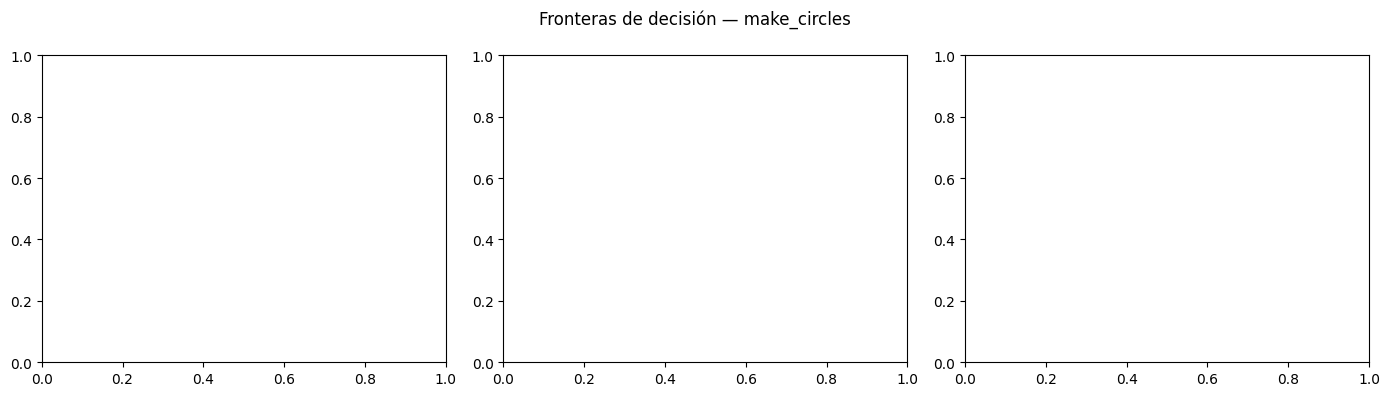


=== Precisión en test ===


In [13]:
# ============================================================
# EJERCICIO 6.2 — MLP con nn.Sequential
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Dataset: make_circles ---
X_circ, y_circ = make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=SEED)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=SEED
)

# Convertir a tensores
X_tr = torch.tensor(X_train_c, dtype=torch.float32)
X_te = torch.tensor(X_test_c,  dtype=torch.float32)
y_tr = torch.tensor(y_train_c, dtype=torch.float32).unsqueeze(1)
y_te = torch.tensor(y_test_c,  dtype=torch.float32).unsqueeze(1)

# --- Parte (a): construir el MLP ---
def construir_mlp(n_hidden):
    """
    Retorna un nn.Sequential con la arquitectura: 2 → n_hidden → 1
    - Capa oculta: nn.Linear(2, n_hidden) + ReLU
    - Capa de salida: nn.Linear(n_hidden, 1) + Sigmoid

    Parámetros:
        n_hidden : int — neuronas en la capa oculta
    """
    # TU CÓDIGO AQUÍ
    # Pista: nn.Sequential(nn.Linear(...), nn.ReLU(), nn.Linear(...), nn.Sigmoid())
    pass

# --- Parte (b): contar parámetros ---
def contar_parametros(modelo):
    """
    Cuenta el total de parámetros entrenables del modelo.
    Retorna un entero.
    """
    # TU CÓDIGO AQUÍ
    # Pista: iterar sobre modelo.parameters(), usar .numel() para contar elementos
    pass

# Verificar:
for n_h in [2, 8, 32]:
    m = construir_mlp(n_h)
    if m is not None:
        n_params = contar_parametros(m)
        print(f"  n_hidden={n_h:>3} → parámetros: {n_params}")

# --- Parte (c): comparar 3 arquitecturas ---
arquitecturas = [2, 8, 32]
colores_arq   = ['tomato', 'darkorange', 'steelblue']
historias = {}
modelos_entrenados = {}

for n_h, color in zip(arquitecturas, colores_arq):
    torch.manual_seed(SEED)
    # TU CÓDIGO AQUÍ
    # 1. Crear el modelo con construir_mlp(n_h)
    # 2. Entrenar durante 500 épocas con lr=0.05, BCELoss, optimizador Adam
    # 3. Guardar historia de pérdida en historias[n_h]
    # 4. Guardar el modelo entrenado en modelos_entrenados[n_h]
    historias[n_h] = []   # reemplazar

# Graficar curvas de pérdida
plt.figure(figsize=(8, 4))
for n_h, color in zip(arquitecturas, colores_arq):
    if historias[n_h]:
        plt.plot(historias[n_h], label=f"n_hidden={n_h}", color=color, linewidth=1.5)
plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title('Comparación de arquitecturas en make_circles')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Visualizar fronteras de decisión
def plot_frontera(modelo, X, y, ax, titulo):
    """
    Grafica la frontera de decisión de un modelo sobre los datos X.
    """
    # Crear grilla
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    grilla = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        Z = modelo(grilla).numpy().reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2,
                colors=['tomato', 'royalblue'])
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='royalblue', s=15, edgecolors='k', lw=0.3)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tomato',    s=15, marker='X', edgecolors='k', lw=0.3)
    ax.set_title(titulo); ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for n_h, ax, color in zip(arquitecturas, axes, colores_arq):
    if n_h in modelos_entrenados and modelos_entrenados[n_h] is not None:
        plot_frontera(modelos_entrenados[n_h], X_train_c, y_train_c, ax,
                      f"n_hidden={n_h}\n({contar_parametros(modelos_entrenados[n_h])} params)")
plt.suptitle("Fronteras de decisión — make_circles", fontsize=12)
plt.tight_layout(); plt.show()

# --- Parte (d): precisión del mejor modelo en test ---
print("\n=== Precisión en test ===")
for n_h in arquitecturas:
    if n_h in modelos_entrenados and modelos_entrenados[n_h] is not None:
        # TU CÓDIGO AQUÍ
        # 1. Hacer forward pass con X_te (sin gradientes)
        # 2. Umbralizar en 0.5 para obtener clase predicha
        # 3. Calcular precisión y mostrarla
        pass

### Preguntas de reflexión — Ejercicio 6.2

1. **Observación:** ¿Qué diferencia visual observás entre las fronteras de decisión de `n_hidden=2` y `n_hidden=32`? ¿Cuál aprendió mejor la forma circular del dataset?

2. **Análisis:** A medida que aumenta `n_hidden`, la pérdida final en entrenamiento ¿disminuye siempre? ¿Cuándo podría ser un problema tener demasiadas neuronas?

3. **Teorema Universal:** El Teorema Universal de Aproximación dice que un MLP con suficiente ancho puede aproximar cualquier función. ¿Por qué el modelo con `n_hidden=2` no logra resolver correctamente `make_circles` aunque teóricamente podría?

4. **Predicción:** Si en lugar de comparar anchos (`n_hidden`), comparases profundidades (1 capa oculta vs 2 vs 3, todas con `n_hidden=8`), ¿esperarías mejoras? ¿Habría algún riesgo al añadir capas?

*→ Escribí tus respuestas aquí*

---

## 🎓 Resumen de temas abordados

| Sección | Tema | Conceptos clave |
|---------|------|----------------|
| 1 | Clasificación binaria | Frontera de decisión, rol de $\mathbf{w}$ y $b$ |
| 2 | Neurona artificial | Forward pass, $z = \mathbf{w}^\top\mathbf{x}+b$, $\hat{y}=\sigma(z)$ |
| 3 | Funciones de costo | MSE, MAE, BCE; gradientes e información |
| 4 | Gradient Descent | Regla de actualización, learning rate, mini-batches |
| 5 | Funciones de activación | Sigmoid, tanh, ReLU, Leaky ReLU, Dying ReLU |
| 6 | MLP | Arquitectura, forward pass, capacidad expresiva |

**Si tienen consultas están invitados a compartirlas en el campus** 🚀